# 07 — Polars Lazy vs Eager

**Benchmark focus:** Polars Lazy vs Polars Eager execution mode.  
**Main evidence:** real-data row-scaling results from `1M`, `10M`, and `50M`.  
**Supporting evidence:** physical scaling, synthetic stress, and Colab/runtime results.

Notebook này phân tích riêng Polars Lazy và Polars Eager. Notebook không chạy benchmark workload; chỉ đọc các CSV đã sinh trong `results/raw/` và filter `status == "ok"` trước khi phân tích chính.


## 1. Research Questions

Notebook này trả lời các câu hỏi:

1. Polars Lazy có consistently faster hơn Polars Eager không?
2. Workload nào hưởng lợi nhiều nhất từ lazy execution?
3. Lazy execution có giảm peak memory không?
4. Có trường hợp nào Eager nhanh hơn hoặc dùng memory thấp hơn Lazy không?
5. Lazy-vs-Eager behavior có thay đổi khi dataset size tăng không?
6. Recommendation cuối cùng: khi nào nên dùng Lazy, khi nào Eager là đủ?


## 2. Setup and Data Loading

Section này load các file Polars cần thiết. Main source là **real row-scaling results** vì notebook này dùng Benchmark 1 làm nguồn kết luận chính. Các nhóm size/stress/Colab chỉ dùng làm supporting evidence để giải thích memory pressure hoặc environment sensitivity.


In [30]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() in {"analysis", "benchmark", "benchmarks", "notebooks"}:
    for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (parent / "results" / "raw").exists():
            PROJECT_ROOT = parent
            break

RAW_DIR = PROJECT_ROOT / "results" / "raw"
TABLE_DIR = PROJECT_ROOT / "results" / "table"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "notebook_07_lazy_vs_eager_polars"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

WORKLOAD_ORDER = ["filter", "groupby", "join", "pipeline"]
ROW_ORDER = ["1M", "10M", "50M"]
FRAMEWORK_ORDER = ["polars_lazy", "polars_eager"]

plt.style.use("seaborn-v0_8-whitegrid")


In [31]:
MAIN_POLARS_FILES = {
    "polars_lazy": RAW_DIR / "polars_real_results.csv",
    "polars_eager": RAW_DIR / "polars_eager_real_results.csv",
}

SUPPORT_SIZE_FILES = {
    "polars_lazy": RAW_DIR / "polars_size_results.csv",
    "polars_eager": RAW_DIR / "polars_eager_size_results.csv",
}

SUPPORT_STRESS_FILES = {
    "polars_lazy": RAW_DIR / "polars_highuid_skewed_results.csv",
    "polars_eager": RAW_DIR / "polars_eager_highuid_skewed_results.csv",
}

SUPPORT_COLAB_FILES = {
    "polars_lazy": RAW_DIR / "polars_colab_results.csv",
    "polars_eager": RAW_DIR / "polars_eager_colab_results.csv",
}


In [32]:
def load_result_group(file_map, analysis_group):
    frames = []
    for framework_group, path in file_map.items():
        if not path.exists():
            print(f"[WARN] Missing file: {path}")
            continue

        df = pd.read_csv(path)
        df["framework_group"] = framework_group
        df["source_file"] = path.name
        df["analysis_group"] = analysis_group
        frames.append(df)

    if not frames:
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)
    if "time_s" in out.columns and "runtime_sec" not in out.columns:
        out["runtime_sec"] = out["time_s"]
    if "peak_memory_mb" in out.columns:
        out["peak_memory_gb"] = out["peak_memory_mb"] / 1024
    return out


def ordered_category(series, order):
    return pd.Categorical(series.astype(str), categories=order, ordered=True)


def save_table(df, name):
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print(f"Saved {path.relative_to(PROJECT_ROOT)}")


def save_current_figure(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved {path.relative_to(PROJECT_ROOT)}")


In [33]:
df_main = load_result_group(MAIN_POLARS_FILES, "main_real_row_scaling")
df_size = load_result_group(SUPPORT_SIZE_FILES, "support_physical_scaling")
df_stress = load_result_group(SUPPORT_STRESS_FILES, "support_synthetic_stress")
df_colab = load_result_group(SUPPORT_COLAB_FILES, "support_colab_environment")

df_all = pd.concat([df_main, df_size, df_stress, df_colab], ignore_index=True)

df_main_ok = df_main[df_main["status"] == "ok"].copy()
df_size_ok = df_size[df_size["status"] == "ok"].copy()
df_stress_ok = df_stress[df_stress["status"] == "ok"].copy()
df_colab_ok = df_colab[df_colab["status"] == "ok"].copy()
df_fail = df_all[df_all["status"] != "ok"].copy()

for frame in [df_main, df_size, df_stress, df_colab, df_all, df_main_ok, df_size_ok, df_stress_ok, df_colab_ok]:
    if not frame.empty:
        frame["workload"] = ordered_category(frame["workload"], WORKLOAD_ORDER)
        frame["framework_group"] = ordered_category(frame["framework_group"], FRAMEWORK_ORDER)


## 3. Result File Inventory and Analysis Boundary

Main analysis:

- `polars_real_results.csv`
- `polars_eager_real_results.csv`

Supporting analysis:

- `polars_size_results.csv`
- `polars_eager_size_results.csv`
- `polars_highuid_skewed_results.csv`
- `polars_eager_highuid_skewed_results.csv`
- `polars_colab_results.csv`
- `polars_eager_colab_results.csv`

**Boundary:** Main lazy-vs-eager conclusions are based on real-data row-scaling results only. Physical scaling, synthetic stress, and Colab results are used only as supporting evidence.


In [34]:
def inventory_rows(file_map, group_label, role):
    rows = []
    for framework_group, path in file_map.items():
        rows.append({
            "analysis_group": group_label,
            "framework_group": framework_group,
            "file": path.name,
            "exists": path.exists(),
            "role": role,
        })
    return rows

inventory = pd.DataFrame(
    inventory_rows(MAIN_POLARS_FILES, "Main real row scaling", "Main analysis")
    + inventory_rows(SUPPORT_SIZE_FILES, "Physical scaling", "Supporting memory-pressure analysis")
    + inventory_rows(SUPPORT_STRESS_FILES, "Synthetic stress", "Supporting skew/cardinality analysis")
    + inventory_rows(SUPPORT_COLAB_FILES, "Colab environment", "Supporting environment sensitivity")
)

save_table(inventory, "polars_lazy_vs_eager_inventory.csv")
inventory


Saved results\table\polars_lazy_vs_eager_inventory.csv


,analysis_group,framework_group,file,exists,role
0,Main real row scaling,polars_lazy,polars_real_results.csv,True,Main analysis
1,Main real row scaling,polars_eager,polars_eager_real_results.csv,True,Main analysis
2,Physical scaling,polars_lazy,polars_size_results.csv,True,Supporting memory-pressure analysis
3,Physical scaling,polars_eager,polars_eager_size_results.csv,True,Supporting memory-pressure analysis
4,Synthetic stress,polars_lazy,polars_highuid_skewed_results.csv,True,Supporting skew/cardinality analysis
5,Synthetic stress,polars_eager,polars_eager_highuid_skewed_results.csv,True,Supporting skew/cardinality analysis
6,Colab environment,polars_lazy,polars_colab_results.csv,True,Supporting environment sensitivity
7,Colab environment,polars_eager,polars_eager_colab_results.csv,True,Supporting environment sensitivity


## 4. Analysis Scope

This analysis focuses on the main real-data benchmark results only.

**Included data:**

- Dataset type: real data
- Frameworks: Polars Lazy and Polars Eager
- Workloads: Filter, GroupBy, Join, and Pipeline
- Dataset sizes: `1M`, `10M`, and `50M`
- Run status: only successful runs where `status == "ok"`

**Main metrics:**

- mean runtime
- mean peak memory
- throughput, when available
- Lazy speedup
- Lazy-to-Eager memory ratio
- dataset-size sensitivity

The main speedup metric is defined as:

```text
lazy_speedup = eager_runtime / lazy_runtime
```

- If `lazy_speedup > 1`, Lazy is faster than Eager.
- If `lazy_speedup < 1`, Eager is faster than Lazy.

The memory ratio is defined as:

> memory_ratio = lazy_peak_memory / eager_peak_memory

- If `memory_ratio < 1`, Lazy uses less peak memory than Eager.
- If `memory_ratio > 1`, Lazy uses more peak memory than Eager.

In [35]:
main_scope = pd.DataFrame({
    "field": ["dataset_type", "frameworks", "workloads", "dataset_sizes", "status_filter", "main_formula"],
    "value": [
        "real data",
        "polars_lazy, polars_eager",
        ", ".join(WORKLOAD_ORDER),
        ", ".join(ROW_ORDER),
        "status == ok",
        "lazy_speedup = eager_runtime / lazy_runtime",
    ],
})
main_scope


,field,value
0,dataset_type,real data
1,frameworks,"polars_lazy, polars_eager"
2,workloads,"filter, groupby, join, pipeline"
3,dataset_sizes,"1M, 10M, 50M"
4,status_filter,status == ok
5,main_formula,lazy_speedup = eager_runtime / lazy_runtime


### Nhận xét

Phạm vi phân tích đã được giới hạn hợp lý để đảm bảo kết quả so sánh giữa Polars Lazy và Polars Eager là nhất quán. Notebook chỉ sử dụng dữ liệu `real data`, bốn workload chính gồm `filter`, `groupby`, `join`, và `pipeline`, ba kích thước dữ liệu `1M`, `10M`, `50M`, đồng thời chỉ giữ lại các lần chạy thành công với `status == "ok"`.

Cách giới hạn này giúp loại bỏ các kết quả lỗi hoặc không hoàn chỉnh, từ đó làm cho các phép so sánh về runtime, memory và speedup đáng tin cậy hơn. Việc tập trung vào cùng một nhóm workload và cùng các kích thước dữ liệu cũng giúp đánh giá được xu hướng thay đổi hiệu năng khi dữ liệu tăng kích thước.

Metric chính `lazy_speedup = eager_runtime / lazy_runtime` là phù hợp cho mục tiêu so sánh hiệu năng. Công thức này dễ diễn giải: nếu giá trị lớn hơn `1`, Lazy chạy nhanh hơn Eager; nếu nhỏ hơn `1`, Eager chạy nhanh hơn Lazy. Ngoài runtime, notebook cũng xét thêm peak memory, throughput và dataset-size sensitivity, nên phần đánh giá không chỉ dựa trên tốc độ mà còn xem xét chi phí bộ nhớ và khả năng mở rộng.

Tuy nhiên, phần này cần lưu ý rằng kết quả chỉ đại diện cho phạm vi benchmark đã chọn. Các kết luận không nên được hiểu là đúng cho mọi loại dữ liệu hoặc mọi workload trong Polars. Hiệu quả của Lazy có thể thay đổi tùy theo cấu trúc truy vấn, kích thước dữ liệu, môi trường chạy và mức độ tối ưu hóa mà Lazy engine có thể áp dụng.

## 5. Data Completeness and Validity Check

Section này kiểm tra đủ tổ hợp `framework_group × workload × dataset_size × status`, required columns, số successful runs, và failed runs nếu có.


In [36]:
REQUIRED_COLUMNS = {
    "framework", "workload", "dataset_size", "n_rows", "run_index",
    "time_s", "peak_memory_mb", "throughput_rows_per_s", "status",
}

validation_rows = []
for label, file_map in [
    ("main", MAIN_POLARS_FILES),
    ("support_size", SUPPORT_SIZE_FILES),
    ("support_stress", SUPPORT_STRESS_FILES),
    ("support_colab", SUPPORT_COLAB_FILES),
]:
    for framework_group, path in file_map.items():
        if not path.exists():
            validation_rows.append({
                "analysis_group": label,
                "framework_group": framework_group,
                "file": path.name,
                "exists": False,
                "missing_columns": "file missing",
            })
            continue
        cols = set(pd.read_csv(path, nrows=1).columns)
        missing = sorted(REQUIRED_COLUMNS - cols)
        validation_rows.append({
            "analysis_group": label,
            "framework_group": framework_group,
            "file": path.name,
            "exists": True,
            "missing_columns": ", ".join(missing) if missing else "",
        })

required_column_check = pd.DataFrame(validation_rows)
required_column_check


,analysis_group,framework_group,file,exists,missing_columns
0,main,polars_lazy,polars_real_results.csv,True,
1,main,polars_eager,polars_eager_real_results.csv,True,
2,support_size,polars_lazy,polars_size_results.csv,True,
3,support_size,polars_eager,polars_eager_size_results.csv,True,
4,support_stress,polars_lazy,polars_highuid_skewed_results.csv,True,
5,support_stress,polars_eager,polars_eager_highuid_skewed_results.csv,True,
6,support_colab,polars_lazy,polars_colab_results.csv,True,
7,support_colab,polars_eager,polars_eager_colab_results.csv,True,


### Nhận xét

Kết quả kiểm tra cho thấy tất cả các file benchmark cần thiết đều tồn tại trong notebook. Các nhóm dữ liệu bao gồm `main`, `support_size`, `support_stress`, và `support_colab` đều có đủ kết quả cho cả hai framework: `polars_lazy` và `polars_eager`.

Cột `exists` đều có giá trị `True`, nghĩa là không có file đầu vào nào bị thiếu. Ngoài ra, cột `missing_columns` đều rỗng, cho thấy các file đều có đầy đủ các cột cần thiết cho quá trình phân tích. Điều này đảm bảo rằng các bước tính toán runtime, peak memory, throughput, speedup và memory ratio có thể được thực hiện nhất quán giữa các nhóm benchmark.

Nhìn chung, dữ liệu đầu vào đạt yêu cầu về tính đầy đủ và hợp lệ ở mức file và schema. Vì vậy, notebook có thể tiếp tục sử dụng các file này cho phân tích chính và các phân tích hỗ trợ mà không cần loại bỏ thêm file nào ở bước kiểm tra ban đầu.

In [37]:
main_result_count = (
    df_main
    .groupby(["framework_group", "workload", "dataset_size", "status"], observed=True)
    .size()
    .rename("n_rows")
    .reset_index()
    .sort_values(["framework_group", "workload", "dataset_size", "status"])
)

main_result_count


,framework_group,workload,dataset_size,status,n_rows
0,polars_lazy,filter,10M,ok,3
1,polars_lazy,filter,1M,ok,3
2,polars_lazy,filter,50M,ok,3
3,polars_lazy,groupby,10M,ok,3
4,polars_lazy,groupby,1M,ok,3
5,polars_lazy,groupby,50M,ok,3
6,polars_lazy,join,10M,ok,3
7,polars_lazy,join,1M,ok,3
8,polars_lazy,join,50M,ok,3
9,polars_lazy,pipeline,10M,ok,3


### Nhận xét

Bảng kiểm tra cho thấy dữ liệu benchmark chính có đầy đủ tất cả các tổ hợp cần thiết giữa `framework_group`, `workload`, `dataset_size`, và `status`. Cả hai framework `polars_lazy` và `polars_eager` đều có kết quả cho bốn workload: `filter`, `groupby`, `join`, và `pipeline`, trên ba kích thước dữ liệu `1M`, `10M`, và `50M`.

Mỗi tổ hợp đều có `status = ok` và `n_rows = 3`, nghĩa là mỗi cấu hình benchmark được chạy lặp lại 3 lần thành công. Điều này giúp kết quả trung bình về runtime, peak memory và các metric dẫn xuất như speedup hoặc memory ratio đáng tin cậy hơn so với chỉ chạy một lần.

Không có tổ hợp nào bị thiếu giữa Lazy và Eager, do đó dữ liệu đủ cân bằng để so sánh trực tiếp giữa hai framework theo từng workload và từng kích thước dataset. Đây là điều kiện quan trọng để các kết luận ở các section sau không bị lệch do thiếu dữ liệu hoặc số lần chạy không đồng đều.

In [38]:
expected = pd.MultiIndex.from_product(
    [FRAMEWORK_ORDER, WORKLOAD_ORDER, ROW_ORDER],
    names=["framework_group", "workload", "dataset_size"],
).to_frame(index=False)

observed_ok = (
    df_main_ok[["framework_group", "workload", "dataset_size"]]
    .drop_duplicates()
    .astype(str)
)

missing_main_ok = (
    expected.merge(observed_ok, on=["framework_group", "workload", "dataset_size"], how="left", indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
)

if missing_main_ok.empty:
    print("No missing successful main-result combinations.")
else:
    display(missing_main_ok)


No missing successful main-result combinations.


In [39]:
failure_summary = (
    df_fail
    .groupby(["analysis_group", "framework_group", "workload", "dataset_size", "status"], observed=True)
    .size()
    .rename("n_failed_rows")
    .reset_index()
    .sort_values(["analysis_group", "framework_group", "workload", "dataset_size"])
)

if failure_summary.empty:
    print("No failed runs found across loaded result groups.")
else:
    display(failure_summary)


No failed runs found across loaded result groups.


## 6. Lazy vs Eager Summary Table

Bảng aggregate chính theo `workload`, `dataset_size`, và `framework_group`. Đây là overview trước khi tính ratio.


In [40]:
summary_by_size = (
    df_main_ok
    .groupby(["workload", "dataset_size", "framework_group"], observed=True)
    .agg(
        mean_runtime=("runtime_sec", "mean"),
        std_runtime=("runtime_sec", "std"),
        mean_memory=("peak_memory_mb", "mean"),
        std_memory=("peak_memory_mb", "std"),
        mean_throughput=("throughput_rows_per_s", "mean"),
        n_runs=("runtime_sec", "count"),
    )
    .reset_index()
)
summary_by_size["workload"] = ordered_category(summary_by_size["workload"], WORKLOAD_ORDER)
summary_by_size["dataset_size"] = ordered_category(summary_by_size["dataset_size"], ROW_ORDER)
summary_by_size["framework_group"] = ordered_category(summary_by_size["framework_group"], FRAMEWORK_ORDER)
summary_by_size = summary_by_size.sort_values(["workload", "dataset_size", "framework_group"])

save_table(summary_by_size, "polars_lazy_vs_eager_summary_by_size.csv")
summary_by_size


Saved results\table\polars_lazy_vs_eager_summary_by_size.csv


,workload,dataset_size,framework_group,mean_runtime,std_runtime,mean_memory,std_memory,mean_throughput,n_runs
2,filter,1M,polars_lazy,0.370933,0.002902,688.360000,16.612610,2.696172e+06,3
3,filter,1M,polars_eager,0.317100,0.008141,763.840000,63.885671,3.155034e+06,3
0,filter,10M,polars_lazy,3.632967,0.149084,3398.586667,17.769137,2.755600e+06,3
1,filter,10M,polars_eager,1.792767,0.074721,4423.836667,109.256074,5.584166e+06,3
4,filter,50M,polars_lazy,30.594000,1.291196,12443.096667,192.644093,1.636270e+06,3
5,filter,50M,polars_eager,53.201967,1.835183,7932.786667,291.522384,9.405647e+05,3
8,groupby,1M,polars_lazy,0.623767,0.005972,1418.766667,79.260857,1.603227e+06,3
9,groupby,1M,polars_eager,0.434533,0.000404,829.133333,32.767930,2.301326e+06,3
6,groupby,10M,polars_lazy,4.271967,0.146836,4922.576667,270.222926,2.342671e+06,3
7,groupby,10M,polars_eager,2.939333,0.107842,5351.020000,134.586572,3.405175e+06,3


### Nhận xét

Bảng summary cho thấy mỗi tổ hợp `workload × dataset_size × framework_group` đều có `n_runs = 3`, nên các giá trị `mean_runtime`, `mean_memory`, và `mean_throughput` được tính từ cùng số lần chạy cho Lazy và Eager. Điều này giúp bảng aggregate đủ cân bằng để làm bước nền trước khi tính các ratio như `lazy_speedup` và `memory_ratio`. :contentReference[oaicite:0]{index=0}

Ở mức tổng quan, hiệu năng giữa Lazy và Eager thay đổi rõ theo workload và kích thước dữ liệu. Với `filter`, Eager nhanh hơn ở `1M` và `10M`, nhưng Lazy lại nhanh hơn ở `50M`. Với `groupby`, Eager nhanh hơn ở dataset nhỏ và trung bình, trong khi Lazy vượt trội ở `50M`. Điều này gợi ý rằng Lazy có lợi hơn khi dữ liệu lớn, đặc biệt ở các workload có nhiều cơ hội tối ưu execution plan.

Ngược lại, `join` là workload mà Eager có lợi thế runtime rõ ràng ở cả ba kích thước dữ liệu. Lazy chậm hơn đáng kể, đặc biệt ở `1M` và `10M`, cho thấy Lazy không phải lúc nào cũng tốt hơn, nhất là với các thao tác join trong benchmark này.

Với `pipeline`, Eager nhanh hơn ở `1M` và `10M`, nhưng Lazy nhanh hơn rất mạnh ở `50M`. Đây là dấu hiệu cho thấy Lazy có thể phát huy hiệu quả tốt hơn trong các pipeline lớn, nơi optimizer có thể kết hợp nhiều bước xử lý và giảm chi phí thực thi tổng thể.

Về memory, Lazy không nhất quán là lựa chọn tiết kiệm bộ nhớ hơn. Một số trường hợp Lazy dùng ít memory hơn, chẳng hạn `filter` ở `1M` và `10M`, hoặc `groupby` ở `10M`. Tuy nhiên, ở nhiều workload lớn như `filter 50M`, `groupby 50M`, `join 50M`, và `pipeline 50M`, Lazy lại dùng peak memory cao hơn Eager. Vì vậy, cần phân tích thêm `memory_ratio` thay vì chỉ dựa vào runtime.

Nhìn chung, bảng này cho thấy không có framework nào thắng tuyệt đối trong mọi trường hợp. Lazy có xu hướng mạnh hơn ở một số workload lớn như `groupby 50M` và `pipeline 50M`, trong khi Eager ổn định hơn ở `join` và nhiều trường hợp dataset nhỏ hơn. Do đó, bước tiếp theo cần tính speedup và memory ratio để định lượng rõ hơn mức chênh lệch giữa hai framework.

## 7. Runtime Comparison: Lazy vs Eager

Section này so sánh absolute runtime để trả lời Lazy có luôn nhanh hơn Eager không, workload nào Lazy nhanh hơn rõ nhất, và workload nào Eager nhanh hơn.


In [41]:
runtime_by_workload = (
    df_main_ok
    .groupby(["workload", "framework_group"], observed=True)
    .agg(
        mean_runtime=("runtime_sec", "mean"),
        std_runtime=("runtime_sec", "std"),
        mean_memory=("peak_memory_mb", "mean"),
        mean_throughput=("throughput_rows_per_s", "mean"),
        n_runs=("runtime_sec", "count"),
    )
    .reset_index()
    .sort_values(["workload", "mean_runtime"])
)

save_table(runtime_by_workload, "polars_lazy_vs_eager_runtime_by_workload.csv")
runtime_by_workload


Saved results\table\polars_lazy_vs_eager_runtime_by_workload.csv


,workload,framework_group,mean_runtime,std_runtime,mean_memory,mean_throughput,n_runs
0,filter,polars_lazy,11.532633,14.380328,5510.014444,2.362681e+06,9
1,filter,polars_eager,18.437278,26.097509,4373.487778,3.226588e+06,9
2,groupby,polars_lazy,7.886122,8.313875,6179.200000,2.204102e+06,9
3,groupby,polars_eager,27.672833,39.004661,5060.890000,2.111503e+06,9
5,join,polars_eager,19.370056,25.648560,4954.616667,1.570685e+06,9
4,join,polars_lazy,36.571611,43.281448,6572.795556,5.676678e+05,9
6,pipeline,polars_lazy,11.172022,7.630113,6788.554444,1.288953e+06,9
7,pipeline,polars_eager,31.850689,43.407436,5895.824444,1.181091e+06,9


### Nhận xét

Bảng runtime comparison cho thấy Lazy không phải lúc nào cũng nhanh hơn Eager. Khi lấy trung bình trên cả ba kích thước dữ liệu (`1M`, `10M`, `50M`), Polars Lazy nhanh hơn ở ba workload: `filter`, `groupby`, và `pipeline`. Tuy nhiên, Polars Eager lại nhanh hơn rõ ràng ở workload `join`.

Với `filter`, Lazy có mean runtime thấp hơn Eager (`11.53s` so với `18.44s`), cho thấy Lazy nhanh hơn khi nhìn trung bình toàn bộ dataset size. Tuy nhiên, kết quả này cần được đọc cùng phân tích theo từng size, vì ở phần summary trước đó Eager nhanh hơn ở `1M` và `10M`, còn Lazy thắng chủ yếu nhờ kết quả tốt hơn ở `50M`.

Với `groupby`, Lazy có lợi thế runtime rất rõ (`7.89s` so với `27.67s`). Đây là workload mà Lazy thể hiện hiệu quả mạnh nhất trong bảng này, đặc biệt do khả năng xử lý tốt hơn khi dataset lớn. Eager có runtime trung bình cao hơn nhiều và độ lệch chuẩn cũng lớn hơn, cho thấy hiệu năng bị ảnh hưởng mạnh bởi các trường hợp dữ liệu lớn.

Với `pipeline`, Lazy cũng nhanh hơn đáng kể (`11.17s` so với `31.85s`). Điều này cho thấy Lazy có thể phát huy lợi thế trong các workflow gồm nhiều bước xử lý, nơi optimizer có thể gom, sắp xếp hoặc tối ưu execution plan trước khi chạy.

Ngược lại, `join` là trường hợp Eager vượt trội. Eager có mean runtime thấp hơn Lazy (`19.37s` so với `36.57s`) và throughput cao hơn nhiều. Điều này cho thấy trong benchmark này, Lazy không tối ưu tốt cho workload join, hoặc chi phí lập kế hoạch/thực thi của Lazy lớn hơn lợi ích tối ưu hóa nhận được.

Nhìn chung, câu trả lời cho câu hỏi “Lazy có luôn nhanh hơn Eager không?” là **không**. Lazy nhanh hơn ở `filter`, `groupby`, và `pipeline` khi xét trung bình toàn bộ dataset size, nhưng Eager nhanh hơn ở `join`. Vì vậy, lựa chọn giữa Lazy và Eager nên dựa trên loại workload và kích thước dữ liệu, thay vì mặc định rằng Lazy luôn tốt hơn.

Saved results\figures\notebook_07_lazy_vs_eager_polars\runtime_by_workload.png


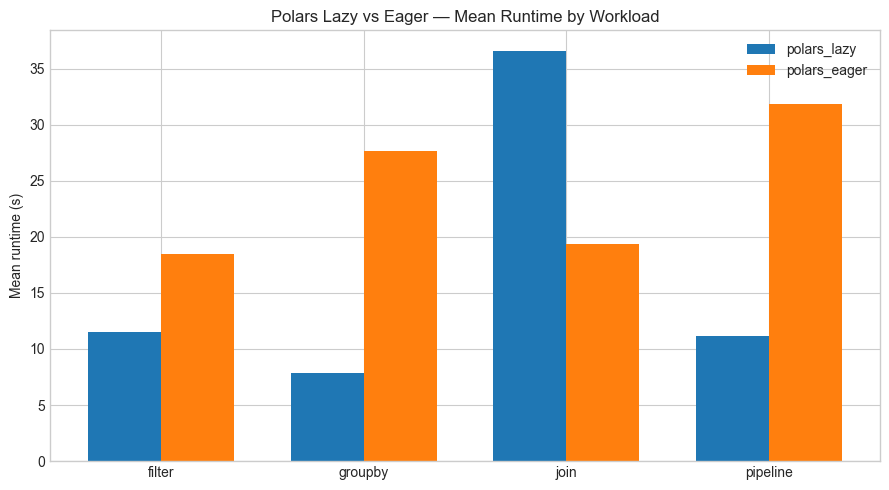

In [42]:
plot_df = runtime_by_workload.copy()
fig, ax = plt.subplots(figsize=(9, 5))
for framework_group in FRAMEWORK_ORDER:
    subset = plot_df[plot_df["framework_group"].astype(str) == framework_group]
    ax.bar(
        np.arange(len(WORKLOAD_ORDER)) + (-0.18 if framework_group == "polars_lazy" else 0.18),
        subset.set_index("workload").reindex(WORKLOAD_ORDER)["mean_runtime"],
        width=0.36,
        label=framework_group,
    )
ax.set_xticks(np.arange(len(WORKLOAD_ORDER)))
ax.set_xticklabels(WORKLOAD_ORDER)
ax.set_ylabel("Mean runtime (s)")
ax.set_title("Polars Lazy vs Eager — Mean Runtime by Workload")
ax.legend()
save_current_figure("runtime_by_workload.png")
plt.show()


### Nhận xét

Biểu đồ cho thấy runtime trung bình của Polars Lazy và Polars Eager khác nhau rõ rệt theo từng workload. Lazy không luôn nhanh hơn Eager trong mọi trường hợp.

Ở `filter`, Lazy có runtime trung bình thấp hơn Eager, cho thấy Lazy nhanh hơn khi xét trung bình trên toàn bộ dataset size. Tuy nhiên, mức chênh lệch không lớn bằng các workload khác.

Ở `groupby`, Lazy nhanh hơn Eager rất rõ. Đây là một trong những workload mà Lazy thể hiện lợi thế mạnh nhất, với mean runtime thấp hơn đáng kể so với Eager. Điều này cho thấy Lazy có thể tận dụng tốt hơn các tối ưu hóa khi thực hiện aggregation.

Ở `pipeline`, Lazy cũng nhanh hơn Eager đáng kể. Kết quả này phù hợp với kỳ vọng rằng Lazy có lợi thế trong các workflow gồm nhiều bước xử lý, vì optimizer có thể lập kế hoạch thực thi trước khi chạy toàn bộ pipeline.

Ngược lại, ở `join`, Eager nhanh hơn Lazy rõ ràng. Đây là workload duy nhất trong biểu đồ mà Lazy có runtime cao hơn Eager. Điều này cho thấy Lazy không phải lựa chọn tốt nhất cho mọi loại thao tác, đặc biệt là join trong benchmark này.

Tóm lại, biểu đồ trả lời trực tiếp câu hỏi chính: **Lazy không luôn nhanh hơn Eager**. Lazy có lợi thế ở `filter`, `groupby`, và `pipeline`, trong khi Eager có lợi thế rõ ở `join`.

Saved results\figures\notebook_07_lazy_vs_eager_polars\runtime_vs_dataset_size_by_workload.png


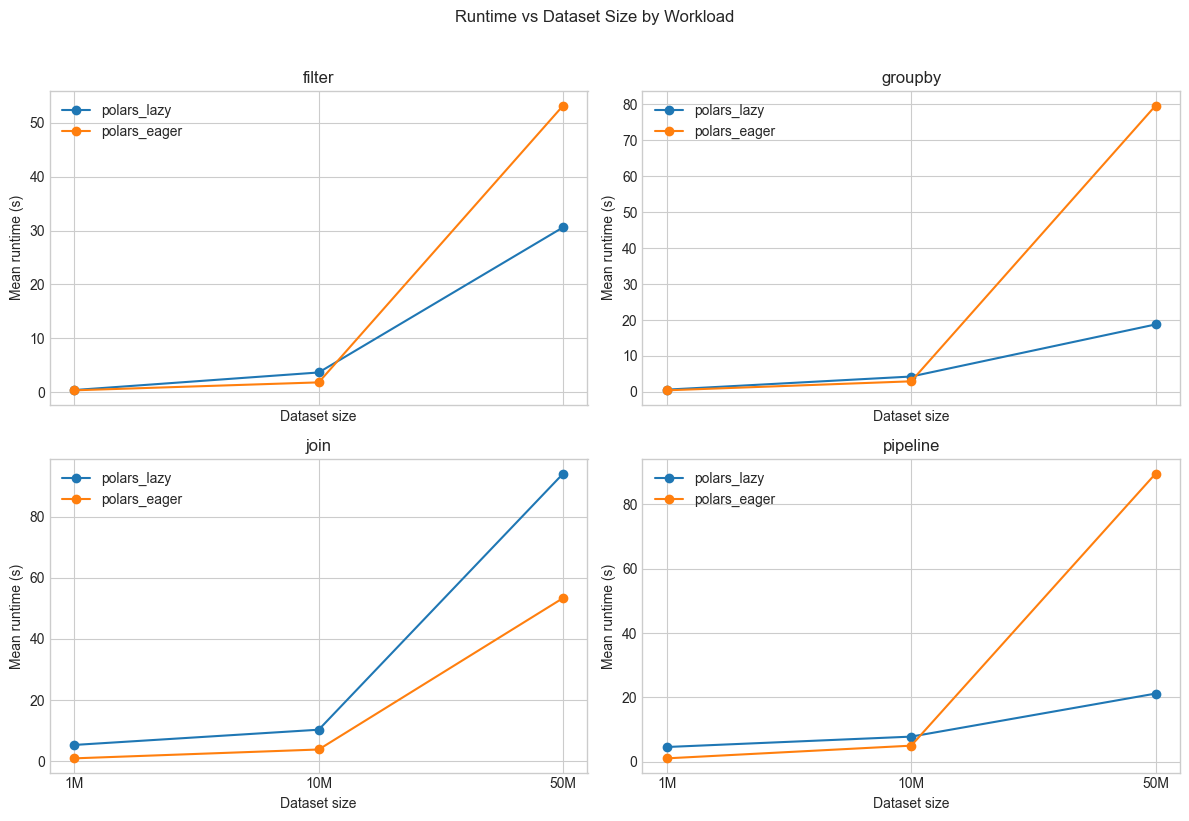

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, workload in zip(axes.ravel(), WORKLOAD_ORDER):
    subset = summary_by_size[summary_by_size["workload"].astype(str) == workload]
    for framework_group in FRAMEWORK_ORDER:
        line = subset[subset["framework_group"].astype(str) == framework_group].set_index("dataset_size").reindex(ROW_ORDER)
        ax.plot(ROW_ORDER, line["mean_runtime"], marker="o", label=framework_group)
    ax.set_title(workload)
    ax.set_ylabel("Mean runtime (s)")
    ax.set_xlabel("Dataset size")
    ax.legend()
fig.suptitle("Runtime vs Dataset Size by Workload", y=1.02)
save_current_figure("runtime_vs_dataset_size_by_workload.png")
plt.show()


### Nhận xét

Biểu đồ cho thấy runtime của cả Polars Lazy và Polars Eager đều tăng khi dataset size tăng từ `1M` lên `50M`, nhưng tốc độ tăng không giống nhau giữa các workload. Điều này cho thấy dataset size ảnh hưởng mạnh đến hiệu năng, và lợi thế của Lazy hoặc Eager thay đổi tùy theo loại thao tác.

Ở `filter`, Eager nhanh hơn Lazy ở `1M` và `10M`, nhưng runtime của Eager tăng rất mạnh ở `50M`. Tại kích thước lớn nhất, Lazy trở nên nhanh hơn rõ rệt. Điều này cho thấy Lazy có thể phát huy lợi thế tốt hơn khi dữ liệu filter đủ lớn.

Ở `groupby`, hai framework khá gần nhau ở `1M` và `10M`, nhưng tại `50M`, runtime của Eager tăng đột biến trong khi Lazy tăng chậm hơn nhiều. Đây là dấu hiệu cho thấy Lazy scale tốt hơn Eager cho workload aggregation khi dữ liệu lớn.

Ở `join`, Eager nhanh hơn Lazy ở cả ba kích thước dữ liệu. Khi dataset tăng lên `50M`, runtime của Lazy tăng rất mạnh và cao hơn đáng kể so với Eager. Vì vậy, trong benchmark này, `join` là workload mà Eager có lợi thế ổn định nhất.

Ở `pipeline`, Eager nhanh hơn ở `1M` và `10M`, nhưng bị tăng runtime rất mạnh ở `50M`. Ngược lại, Lazy tăng chậm hơn và trở thành lựa chọn nhanh hơn rõ rệt ở dataset lớn. Điều này cho thấy Lazy đặc biệt có lợi trong các pipeline lớn, nơi optimizer có thể tối ưu nhiều bước xử lý cùng lúc.

Tóm lại, Lazy không luôn nhanh hơn ở dataset nhỏ hoặc trung bình, nhưng có xu hướng scale tốt hơn ở một số workload lớn như `filter`, `groupby`, và `pipeline`. Riêng với `join`, Eager vẫn là lựa chọn tốt hơn trong toàn bộ phạm vi dataset size của benchmark này.

## 8. Lazy Speedup over Eager

Đây là section chính của notebook. Speedup được tính trong cùng `workload + dataset_size`:

```text
lazy_speedup = eager_runtime / lazy_runtime
```

Interpretation:

- `lazy_speedup > 1.0` => Lazy faster
- `lazy_speedup = 1.0` => similar
- `lazy_speedup < 1.0` => Eager faster


In [44]:
runtime_pivot = summary_by_size.pivot_table(
    index=["workload", "dataset_size"],
    columns="framework_group",
    values="mean_runtime",
    observed=True,
).reset_index()

speedup_by_size = runtime_pivot.rename_axis(None, axis=1).copy()
speedup_by_size["lazy_speedup"] = speedup_by_size["polars_eager"] / speedup_by_size["polars_lazy"]
speedup_by_size["faster_mode"] = np.select(
    [speedup_by_size["lazy_speedup"] > 1.05, speedup_by_size["lazy_speedup"] < 0.95],
    ["Lazy", "Eager"],
    default="Similar",
)
speedup_by_size = speedup_by_size.sort_values(["workload", "dataset_size"])

save_table(speedup_by_size, "polars_lazy_speedup_by_workload_size.csv")
speedup_by_size


Saved results\table\polars_lazy_speedup_by_workload_size.csv


,workload,dataset_size,polars_lazy,polars_eager,lazy_speedup,faster_mode
0,filter,1M,0.370933,0.317100,0.854871,Eager
1,filter,10M,3.632967,1.792767,0.493472,Eager
2,filter,50M,30.594000,53.201967,1.738967,Lazy
3,groupby,1M,0.623767,0.434533,0.696628,Eager
4,groupby,10M,4.271967,2.939333,0.688052,Eager
5,groupby,50M,18.762633,79.644633,4.244854,Lazy
6,join,1M,5.298400,0.907133,0.171209,Eager
7,join,10M,10.287167,3.807700,0.370141,Eager
8,join,50M,94.129267,53.395333,0.567255,Eager
9,pipeline,1M,4.559833,1.031333,0.226178,Eager


### Nhận xét

Bảng speedup cho thấy Lazy không luôn nhanh hơn Eager. Trong tổng số 12 tổ hợp `workload × dataset_size`, Lazy chỉ nhanh hơn ở 3 trường hợp: `filter 50M`, `groupby 50M`, và `pipeline 50M`. Các trường hợp còn lại đều có `lazy_speedup < 1.0`, nghĩa là Eager nhanh hơn.

Kết quả này cho thấy lợi thế của Lazy chủ yếu xuất hiện ở dataset lớn. Với `filter`, Lazy chậm hơn Eager ở `1M` và `10M`, nhưng nhanh hơn ở `50M` với speedup khoảng `1.74x`. Điều này cho thấy Lazy chỉ bắt đầu có lợi khi dữ liệu đủ lớn để optimizer bù được chi phí lập kế hoạch thực thi.

Với `groupby`, Lazy thua nhẹ ở `1M` và `10M`, nhưng thắng rất mạnh ở `50M` với speedup khoảng `4.24x`. Đây là một trong hai workload có lợi thế Lazy rõ nhất trong benchmark này, cho thấy Lazy scale tốt hơn Eager cho aggregation khi dữ liệu lớn.

Với `pipeline`, Lazy cũng thua ở `1M` và `10M`, nhưng đạt speedup khoảng `4.23x` ở `50M`. Kết quả này cho thấy Lazy đặc biệt phù hợp với pipeline lớn, nơi nhiều bước xử lý có thể được tối ưu cùng lúc trước khi thực thi.

Ngược lại, `join` là workload mà Eager thắng ở toàn bộ dataset size. Lazy speedup luôn nhỏ hơn `1.0`, từ `0.17x` ở `1M`, `0.37x` ở `10M`, đến `0.57x` ở `50M`. Điều này cho thấy trong benchmark này, Lazy không mang lại lợi thế runtime cho join.

Tóm lại, kết quả speedup trả lời rõ câu hỏi chính: **Lazy không phải lúc nào cũng nhanh hơn Eager**. Lazy có lợi thế rõ ở một số workload lớn, đặc biệt là `groupby 50M` và `pipeline 50M`, nhưng Eager vẫn là lựa chọn tốt hơn cho dataset nhỏ/trung bình và cho workload `join`.

In [45]:
mean_speedup_by_workload = (
    speedup_by_size
    .groupby("workload", observed=True)
    .agg(
        mean_lazy_speedup=("lazy_speedup", "mean"),
        min_lazy_speedup=("lazy_speedup", "min"),
        max_lazy_speedup=("lazy_speedup", "max"),
        n_dataset_sizes=("lazy_speedup", "count"),
    )
    .reset_index()
)
mean_speedup_by_workload["overall_faster_mode"] = np.select(
    [mean_speedup_by_workload["mean_lazy_speedup"] > 1.05, mean_speedup_by_workload["mean_lazy_speedup"] < 0.95],
    ["Lazy", "Eager"],
    default="Similar",
)
mean_speedup_by_workload = mean_speedup_by_workload.sort_values("mean_lazy_speedup", ascending=False)

save_table(mean_speedup_by_workload, "polars_lazy_speedup_by_workload.csv")
mean_speedup_by_workload


Saved results\table\polars_lazy_speedup_by_workload.csv


,workload,mean_lazy_speedup,min_lazy_speedup,max_lazy_speedup,n_dataset_sizes,overall_faster_mode
1,groupby,1.876511,0.688052,4.244854,3,Lazy
3,pipeline,1.698375,0.226178,4.229776,3,Lazy
0,filter,1.029103,0.493472,1.738967,3,Similar
2,join,0.369535,0.171209,0.567255,3,Eager


### Nhận xét

Bảng tổng hợp speedup theo workload cho thấy `groupby` là workload có lợi nhất cho Lazy khi xét trung bình trên ba kích thước dữ liệu, với `mean_lazy_speedup ≈ 1.88x`. Tuy nhiên, giá trị `min_lazy_speedup < 1.0` cho thấy Lazy không nhanh hơn ở mọi dataset size; lợi thế trung bình chủ yếu đến từ mức speedup rất cao ở dataset lớn nhất.

`pipeline` cũng có lợi rõ cho Lazy, với `mean_lazy_speedup ≈ 1.70x` và `max_lazy_speedup ≈ 4.23x`. Tương tự `groupby`, Lazy không thắng ở tất cả các kích thước dữ liệu, nhưng đạt lợi thế lớn khi dataset tăng lên `50M`.

`filter` có `mean_lazy_speedup ≈ 1.03x`, gần bằng `1.0`, nên được phân loại là `Similar`. Điều này cho thấy nếu chỉ xét trung bình, Lazy và Eager khá tương đương ở workload này. Tuy nhiên, range từ `0.49x` đến `1.74x` cho thấy kết quả phụ thuộc mạnh vào dataset size: Eager tốt hơn ở một số size nhỏ hơn, còn Lazy tốt hơn ở size lớn.

`join` là workload duy nhất có `overall_faster_mode = Eager`, với `mean_lazy_speedup ≈ 0.37x`. Vì toàn bộ speedup đều nhỏ hơn `1.0`, Eager nhanh hơn Lazy nhất quán trên cả ba kích thước dữ liệu.

Tóm lại, xét theo workload, Lazy có lợi nhất ở `groupby` và `pipeline`, gần tương đương Eager ở `filter`, nhưng kém rõ rệt ở `join`. Kết quả này củng cố kết luận rằng Lazy không phải lựa chọn tối ưu mặc định cho mọi workload.

Saved results\figures\notebook_07_lazy_vs_eager_polars\lazy_speedup_by_workload.png


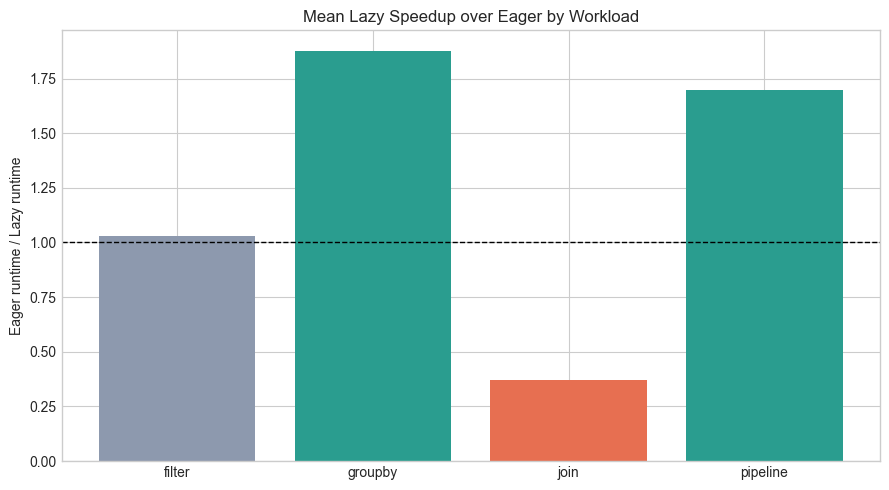

In [46]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_speedup = mean_speedup_by_workload.set_index("workload").reindex(WORKLOAD_ORDER)
colors = ["#2a9d8f" if value > 1.05 else "#e76f51" if value < 0.95 else "#8d99ae" for value in plot_speedup["mean_lazy_speedup"]]
ax.bar(plot_speedup.index.astype(str), plot_speedup["mean_lazy_speedup"], color=colors)
ax.axhline(1.0, color="black", linewidth=1, linestyle="--")
ax.set_ylabel("Eager runtime / Lazy runtime")
ax.set_title("Mean Lazy Speedup over Eager by Workload")
save_current_figure("lazy_speedup_by_workload.png")
plt.show()


### Nhận xét

Biểu đồ cho thấy mức speedup trung bình của Lazy so với Eager khác nhau rõ theo workload. Đường ngang tại `1.0` là mốc so sánh: giá trị lớn hơn `1.0` nghĩa là Lazy nhanh hơn Eager, còn giá trị nhỏ hơn `1.0` nghĩa là Eager nhanh hơn Lazy.

`groupby` có mean lazy speedup cao nhất, khoảng `1.88x`, cho thấy đây là workload mà Lazy có lợi thế trung bình mạnh nhất. `pipeline` cũng có lợi rõ ràng với speedup khoảng `1.70x`. Hai workload này nằm cao hơn đáng kể so với mốc `1.0`, cho thấy Lazy thường có lợi hơn khi workload có nhiều cơ hội tối ưu execution plan.

`filter` nằm rất gần mốc `1.0`, với speedup trung bình khoảng `1.03x`. Điều này cho thấy Lazy và Eager gần như tương đương khi xét trung bình, mặc dù kết quả theo từng dataset size có thể khác nhau.

Ngược lại, `join` nằm dưới xa mốc `1.0`, với mean speedup khoảng `0.37x`. Điều này nghĩa là Eager nhanh hơn Lazy rõ rệt trong workload join của benchmark này.

Tóm lại, biểu đồ củng cố kết luận rằng Lazy không luôn nhanh hơn Eager. Lazy có lợi thế rõ ở `groupby` và `pipeline`, gần tương đương ở `filter`, nhưng kém hơn Eager đáng kể ở `join`.

## 9. Memory Comparison: Lazy vs Eager

Mục tiêu của section này là kiểm tra Lazy có giảm peak memory không.

```text
lazy_memory_ratio = lazy_memory / eager_memory
```

Interpretation:

- `lazy_memory_ratio < 1.0` => Lazy uses less memory
- `lazy_memory_ratio > 1.0` => Lazy uses more memory


In [47]:
memory_pivot = summary_by_size.pivot_table(
    index=["workload", "dataset_size"],
    columns="framework_group",
    values="mean_memory",
    observed=True,
).reset_index()

memory_ratio_by_size = memory_pivot.rename_axis(None, axis=1).copy()
memory_ratio_by_size["lazy_memory_ratio"] = memory_ratio_by_size["polars_lazy"] / memory_ratio_by_size["polars_eager"]
memory_ratio_by_size["lower_memory_mode"] = np.select(
    [memory_ratio_by_size["lazy_memory_ratio"] < 0.95, memory_ratio_by_size["lazy_memory_ratio"] > 1.05],
    ["Lazy", "Eager"],
    default="Similar",
)
memory_ratio_by_size = memory_ratio_by_size.sort_values(["workload", "dataset_size"])

save_table(memory_ratio_by_size, "polars_lazy_memory_ratio_by_workload_size.csv")
memory_ratio_by_size


Saved results\table\polars_lazy_memory_ratio_by_workload_size.csv


,workload,dataset_size,polars_lazy,polars_eager,lazy_memory_ratio,lower_memory_mode
0,filter,1M,688.360000,763.840000,0.901183,Lazy
1,filter,10M,3398.586667,4423.836667,0.768244,Lazy
2,filter,50M,12443.096667,7932.786667,1.568566,Eager
3,groupby,1M,1418.766667,829.133333,1.711144,Eager
4,groupby,10M,4922.576667,5351.020000,0.919932,Lazy
5,groupby,50M,12196.256667,9002.516667,1.354761,Eager
6,join,1M,2261.956667,2124.096667,1.064903,Eager
7,join,10M,5458.736667,5639.506667,0.967946,Similar
8,join,50M,11997.693333,7100.246667,1.689757,Eager
9,pipeline,1M,2349.560000,1617.373333,1.452701,Eager


### Nhận xét

Bảng memory comparison cho thấy Lazy không luôn giảm peak memory so với Eager. Trong 12 tổ hợp `workload × dataset_size`, Lazy chỉ dùng ít memory hơn ở một số trường hợp như `filter 1M`, `filter 10M`, và `groupby 10M`. Các trường hợp còn lại phần lớn có `lazy_memory_ratio > 1.0`, nghĩa là Lazy dùng nhiều peak memory hơn Eager.

Với `filter`, Lazy dùng ít memory hơn ở `1M` và `10M`, với memory ratio lần lượt khoảng `0.90` và `0.77`. Tuy nhiên, ở `50M`, ratio tăng lên khoảng `1.57`, nghĩa là Lazy dùng nhiều memory hơn Eager đáng kể. Điều này cho thấy lợi thế memory của Lazy trong workload filter không ổn định khi dataset lớn hơn.

Với `groupby`, Lazy dùng nhiều memory hơn ở `1M`, ít hơn nhẹ ở `10M`, nhưng lại dùng nhiều hơn ở `50M`. Mặc dù Lazy có lợi thế runtime rất lớn ở `groupby 50M`, kết quả memory cho thấy lợi thế tốc độ này đi kèm với peak memory cao hơn.

Với `join`, memory giữa Lazy và Eager gần tương đương ở `10M`, nhưng Eager dùng ít memory hơn ở `1M` và đặc biệt là `50M`. Kết hợp với kết quả runtime trước đó, `join` là workload mà Eager có lợi thế cả về tốc độ lẫn memory trong benchmark này.

Với `pipeline`, Lazy dùng nhiều memory hơn Eager ở cả ba kích thước dữ liệu. Dù Lazy nhanh hơn rất rõ ở `50M`, nó vẫn có peak memory cao hơn Eager. Vì vậy, với pipeline lớn, Lazy có thể là lựa chọn tốt về runtime nhưng không nhất thiết tốt hơn về memory.

Tóm lại, câu trả lời cho câu hỏi “Lazy có giảm peak memory không?” là **không nhất quán**. Lazy có thể giảm memory trong một vài trường hợp, nhưng trong benchmark chính này, Eager thường có peak memory thấp hơn, đặc biệt ở các workload lớn như `filter 50M`, `groupby 50M`, `join 50M`, và `pipeline 50M`.

In [48]:
mean_memory_ratio_by_workload = (
    memory_ratio_by_size
    .groupby("workload", observed=True)
    .agg(
        mean_lazy_memory_ratio=("lazy_memory_ratio", "mean"),
        min_lazy_memory_ratio=("lazy_memory_ratio", "min"),
        max_lazy_memory_ratio=("lazy_memory_ratio", "max"),
        n_dataset_sizes=("lazy_memory_ratio", "count"),
    )
    .reset_index()
)
mean_memory_ratio_by_workload["overall_lower_memory_mode"] = np.select(
    [mean_memory_ratio_by_workload["mean_lazy_memory_ratio"] < 0.95, mean_memory_ratio_by_workload["mean_lazy_memory_ratio"] > 1.05],
    ["Lazy", "Eager"],
    default="Similar",
)
mean_memory_ratio_by_workload = mean_memory_ratio_by_workload.sort_values("mean_lazy_memory_ratio")

save_table(mean_memory_ratio_by_workload, "polars_lazy_memory_ratio_by_workload.csv")
mean_memory_ratio_by_workload


Saved results\table\polars_lazy_memory_ratio_by_workload.csv


,workload,mean_lazy_memory_ratio,min_lazy_memory_ratio,max_lazy_memory_ratio,n_dataset_sizes,overall_lower_memory_mode
0,filter,1.079331,0.768244,1.568566,3,Eager
3,pipeline,1.224528,1.076669,1.452701,3,Eager
2,join,1.240869,0.967946,1.689757,3,Eager
1,groupby,1.328612,0.919932,1.711144,3,Eager


### Nhận xét

Bảng tổng hợp memory ratio theo workload cho thấy Eager có lợi thế về peak memory ở cả bốn workload khi xét trung bình trên ba kích thước dữ liệu. Tất cả các workload đều có `mean_lazy_memory_ratio > 1.0`, nghĩa là Lazy dùng nhiều peak memory hơn Eager về mặt trung bình.

`filter` là workload có memory ratio trung bình thấp nhất, khoảng `1.08x`. Điều này cho thấy memory của Lazy và Eager khá gần nhau ở workload này, mặc dù Lazy vẫn dùng nhiều memory hơn khi xét trung bình. Tuy nhiên, giá trị `min_lazy_memory_ratio = 0.77` cho thấy Lazy vẫn có thể dùng ít memory hơn ở một số dataset size nhỏ hoặc trung bình.

`pipeline` và `join` có mean memory ratio lần lượt khoảng `1.22x` và `1.24x`, cho thấy Lazy dùng nhiều peak memory hơn Eager tương đối rõ. Với `join`, khoảng dao động khá lớn, từ gần tương đương ở một số size đến cao hơn đáng kể ở dataset lớn.

`groupby` có mean memory ratio cao nhất, khoảng `1.33x`. Điều này đáng chú ý vì `groupby` cũng là workload mà Lazy có lợi thế runtime mạnh nhất. Nói cách khác, trong benchmark này, Lazy cải thiện tốc độ cho `groupby`, nhưng đánh đổi bằng peak memory cao hơn trung bình.

Tóm lại, kết quả memory không ủng hộ giả thuyết rằng Lazy luôn tiết kiệm bộ nhớ hơn Eager. Trong benchmark chính này, Eager là lựa chọn có peak memory thấp hơn về mặt trung bình ở tất cả workload, trong khi Lazy có thể nhanh hơn ở một số workload nhưng thường đi kèm chi phí memory cao hơn.

Saved results\figures\notebook_07_lazy_vs_eager_polars\lazy_memory_ratio_by_workload.png


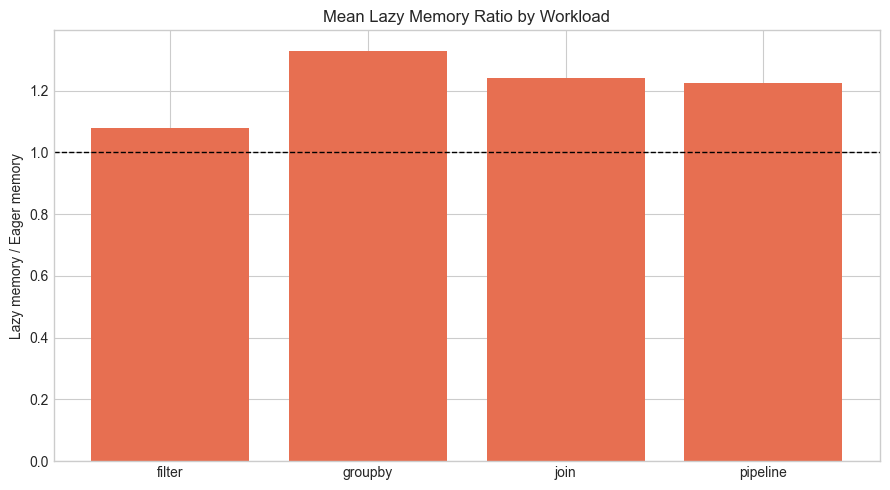

In [49]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_memory = mean_memory_ratio_by_workload.set_index("workload").reindex(WORKLOAD_ORDER)
colors = ["#2a9d8f" if value < 0.95 else "#e76f51" if value > 1.05 else "#8d99ae" for value in plot_memory["mean_lazy_memory_ratio"]]
ax.bar(plot_memory.index.astype(str), plot_memory["mean_lazy_memory_ratio"], color=colors)
ax.axhline(1.0, color="black", linewidth=1, linestyle="--")
ax.set_ylabel("Lazy memory / Eager memory")
ax.set_title("Mean Lazy Memory Ratio by Workload")
save_current_figure("lazy_memory_ratio_by_workload.png")
plt.show()


### Nhận xét

Biểu đồ cho thấy `mean_lazy_memory_ratio` của tất cả workload đều lớn hơn `1.0`. Điều này nghĩa là, khi xét trung bình trên các dataset size, Polars Lazy dùng nhiều peak memory hơn Polars Eager ở cả bốn workload.

`filter` là workload gần mốc `1.0` nhất, với memory ratio chỉ cao hơn Eager một chút. Điều này cho thấy mức chênh lệch memory giữa Lazy và Eager ở `filter` không quá lớn khi xét trung bình.

`groupby` có memory ratio cao nhất, nghĩa là Lazy dùng nhiều peak memory hơn Eager rõ nhất trong workload này. Đây là điểm đáng chú ý vì ở phần runtime, `groupby` lại là workload mà Lazy có speedup cao nhất. Do đó, lợi thế tốc độ của Lazy trong `groupby` có thể đi kèm với chi phí bộ nhớ cao hơn.

`join` và `pipeline` cũng đều nằm trên mốc `1.0`, cho thấy Eager có lợi thế memory ở hai workload này. Với `pipeline`, dù Lazy nhanh hơn rõ ở dataset lớn, biểu đồ này cho thấy Lazy không đồng thời tiết kiệm memory.

Tóm lại, biểu đồ không ủng hộ giả thuyết rằng Lazy luôn tiết kiệm bộ nhớ hơn Eager. Trong benchmark chính này, Eager có peak memory thấp hơn trung bình ở tất cả workload, còn Lazy có thể nhanh hơn ở một số workload nhưng thường đánh đổi bằng mức sử dụng memory cao hơn.

Saved results\figures\notebook_07_lazy_vs_eager_polars\memory_by_workload.png


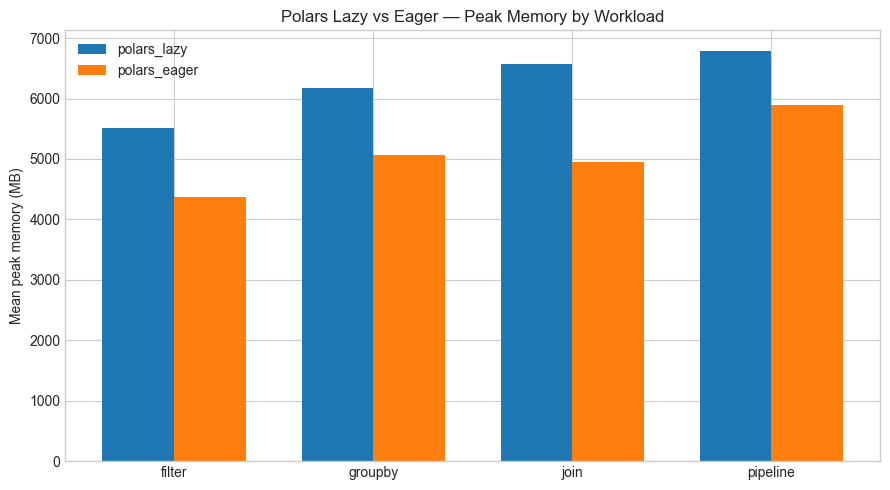

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))
for framework_group in FRAMEWORK_ORDER:
    subset = runtime_by_workload[runtime_by_workload["framework_group"].astype(str) == framework_group]
    ax.bar(
        np.arange(len(WORKLOAD_ORDER)) + (-0.18 if framework_group == "polars_lazy" else 0.18),
        subset.set_index("workload").reindex(WORKLOAD_ORDER)["mean_memory"],
        width=0.36,
        label=framework_group,
    )
ax.set_xticks(np.arange(len(WORKLOAD_ORDER)))
ax.set_xticklabels(WORKLOAD_ORDER)
ax.set_ylabel("Mean peak memory (MB)")
ax.set_title("Polars Lazy vs Eager — Peak Memory by Workload")
ax.legend()
save_current_figure("memory_by_workload.png")
plt.show()


### Nhận xét

Biểu đồ peak memory cho thấy Polars Lazy dùng nhiều bộ nhớ hơn Polars Eager ở cả bốn workload khi xét trung bình theo workload. Điều này phù hợp với kết quả `lazy_memory_ratio` trước đó, trong đó tất cả workload đều có memory ratio trung bình lớn hơn `1.0`.

Mức chênh lệch nhỏ nhất xuất hiện ở `pipeline`, nơi Lazy vẫn dùng nhiều memory hơn Eager nhưng khoảng cách không quá lớn so với các workload khác. Với `filter`, `groupby`, và đặc biệt là `join`, Lazy có peak memory cao hơn khá rõ.

Kết quả này cho thấy Lazy không nên được xem là mặc định tiết kiệm memory hơn Eager. Trong benchmark chính này, Lazy có thể đem lại lợi thế runtime ở một số workload như `groupby` và `pipeline`, nhưng lợi thế đó đi kèm với chi phí peak memory cao hơn.

Tóm lại, nếu mục tiêu chính là giảm peak memory, Eager là lựa chọn tốt hơn trong các workload được benchmark. Nếu mục tiêu chính là giảm runtime, cần cân nhắc theo từng workload và dataset size, vì Lazy chỉ có lợi thế tốc độ ở một số trường hợp nhất định.

## 10. Dataset-Size Sensitivity

Section này phân tích Lazy vs Eager khi row count tăng từ `1M` lên `50M`.

Các chỉ số chính:

- `runtime_growth_50M_vs_1M`
- `memory_growth_50M_vs_1M`
- thay đổi lazy speedup từ `1M` sang `50M`


In [51]:
def growth_table(summary_df, metric_col, output_col):
    wide = summary_df.pivot_table(
        index=["workload", "framework_group"],
        columns="dataset_size",
        values=metric_col,
        observed=True,
    ).reset_index().rename_axis(None, axis=1)
    wide[output_col] = wide["50M"] / wide["1M"]
    return wide

runtime_growth = growth_table(summary_by_size, "mean_runtime", "runtime_growth_50M_vs_1M")
memory_growth = growth_table(summary_by_size, "mean_memory", "memory_growth_50M_vs_1M")

size_sensitivity = runtime_growth[["workload", "framework_group", "runtime_growth_50M_vs_1M"]].merge(
    memory_growth[["workload", "framework_group", "memory_growth_50M_vs_1M"]],
    on=["workload", "framework_group"],
    how="outer",
)

speedup_wide = speedup_by_size.pivot_table(
    index="workload",
    columns="dataset_size",
    values="lazy_speedup",
    observed=True,
).reset_index().rename_axis(None, axis=1)
speedup_wide["speedup_change_50M_minus_1M"] = speedup_wide["50M"] - speedup_wide["1M"]

save_table(size_sensitivity, "polars_lazy_vs_eager_size_sensitivity.csv")
save_table(speedup_wide, "polars_lazy_speedup_size_change.csv")

size_sensitivity


Saved results\table\polars_lazy_vs_eager_size_sensitivity.csv
Saved results\table\polars_lazy_speedup_size_change.csv


,workload,framework_group,runtime_growth_50M_vs_1M,memory_growth_50M_vs_1M
0,filter,polars_lazy,82.478433,18.076438
1,filter,polars_eager,167.776621,10.385404
2,groupby,polars_lazy,30.079570,8.596379
3,groupby,polars_eager,183.287742,10.857743
4,join,polars_lazy,17.765602,5.304122
5,join,polars_eager,58.861615,3.342714
6,pipeline,polars_lazy,4.642692,5.147198
7,pipeline,polars_eager,86.823465,6.534904


### Nhận xét

Bảng dataset-size sensitivity cho thấy runtime và memory đều tăng khi dataset size tăng từ `1M` lên `50M`, nhưng mức tăng khác nhau rất rõ giữa Lazy và Eager. Nhìn chung, Lazy có runtime growth thấp hơn Eager ở cả bốn workload, cho thấy Lazy scale tốt hơn về runtime khi row count tăng lớn.

Ở `filter`, runtime của Lazy tăng khoảng `82.48x`, trong khi Eager tăng khoảng `167.78x`. Điều này giải thích vì sao Eager nhanh hơn ở dataset nhỏ nhưng Lazy lại vượt lên ở `50M`. Tuy nhiên, memory của Lazy tăng mạnh hơn Eager (`18.08x` so với `10.39x`), cho thấy lợi thế runtime của Lazy đi kèm chi phí memory cao hơn khi dữ liệu lớn.

Ở `groupby`, sự khác biệt về runtime growth rất rõ. Lazy tăng khoảng `30.08x`, trong khi Eager tăng tới `183.29x`. Đây là bằng chứng mạnh cho thấy Lazy scale tốt hơn nhiều cho aggregation khi dataset lớn. Về memory, Lazy cũng tăng ít hơn Eager (`8.60x` so với `10.86x`), dù peak memory tuyệt đối ở `50M` vẫn có thể cao hơn Eager.

Ở `join`, Lazy có runtime growth thấp hơn Eager (`17.77x` so với `58.86x`), nhưng điều này không có nghĩa Lazy nhanh hơn. Do Lazy đã chậm hơn nhiều ở `1M`, nên dù tốc độ tăng thấp hơn, runtime tuyệt đối của Lazy ở `50M` vẫn cao hơn Eager. Về memory, Lazy cũng tăng nhiều hơn Eager (`5.30x` so với `3.34x`).

Ở `pipeline`, Lazy scale tốt nhất về runtime, chỉ tăng khoảng `4.64x` từ `1M` lên `50M`, trong khi Eager tăng tới `86.82x`. Đây là lý do Lazy có lợi thế rất rõ ở `pipeline 50M`. Memory growth của Lazy cũng thấp hơn Eager (`5.15x` so với `6.53x`), nhưng Lazy vẫn có thể dùng nhiều peak memory hơn ở mức tuyệt đối.

Tóm lại, khi dataset size tăng, Lazy thường có runtime growth thấp hơn Eager, đặc biệt ở `groupby` và `pipeline`. Tuy nhiên, lợi thế scale về runtime không đồng nghĩa với peak memory thấp hơn. Vì vậy, Lazy phù hợp hơn cho một số workload lớn nếu mục tiêu chính là runtime, còn memory vẫn cần được đánh giá riêng.

In [52]:
speedup_wide

,workload,1M,10M,50M,speedup_change_50M_minus_1M
0,filter,0.854871,0.493472,1.738967,0.884097
1,groupby,0.696628,0.688052,4.244854,3.548226
2,join,0.171209,0.370141,0.567255,0.396046
3,pipeline,0.226178,0.639171,4.229776,4.003598


### Nhận xét

Bảng này cho thấy Lazy có xu hướng cải thiện tương đối so với Eager khi dataset size tăng từ `1M` lên `50M`. Cả bốn workload đều có `speedup_change_50M_minus_1M > 0`, nghĩa là Lazy trở nên cạnh tranh hơn ở dataset lớn, dù không phải workload nào Lazy cũng vượt qua Eager.

`pipeline` có mức cải thiện speedup lớn nhất, tăng khoảng `4.00` điểm, từ `0.23x` ở `1M` lên `4.23x` ở `50M`. Điều này cho thấy Lazy scale rất tốt cho pipeline lớn và chuyển từ chậm hơn Eager ở dataset nhỏ sang nhanh hơn rõ rệt ở dataset lớn.

`groupby` cũng có mức cải thiện rất mạnh, tăng khoảng `3.55` điểm, từ `0.70x` ở `1M` lên `4.24x` ở `50M`. Đây là bằng chứng rõ rằng Lazy phát huy lợi thế mạnh ở aggregation khi dữ liệu lớn.

`filter` có cải thiện nhẹ hơn, từ `0.85x` lên `1.74x`. Lazy vẫn thua Eager ở `1M` và `10M`, nhưng vượt lên ở `50M`, cho thấy workload này cũng có lợi cho Lazy khi dữ liệu đủ lớn.

`join` cũng có speedup tăng từ `0.17x` lên `0.57x`, nhưng toàn bộ giá trị vẫn nhỏ hơn `1.0`. Điều này nghĩa là Lazy có cải thiện khi dataset lớn hơn, nhưng vẫn chưa đủ để vượt Eager trong workload join.

Tóm lại, dataset size là yếu tố rất quan trọng trong so sánh Lazy và Eager. Lazy thường không có lợi ở dataset nhỏ, nhưng trở nên mạnh hơn khi dữ liệu lớn, đặc biệt ở `pipeline` và `groupby`. Tuy nhiên, với `join`, Eager vẫn nhanh hơn ở mọi kích thước dữ liệu.

Saved results\figures\notebook_07_lazy_vs_eager_polars\runtime_vs_size_separate_workloads.png


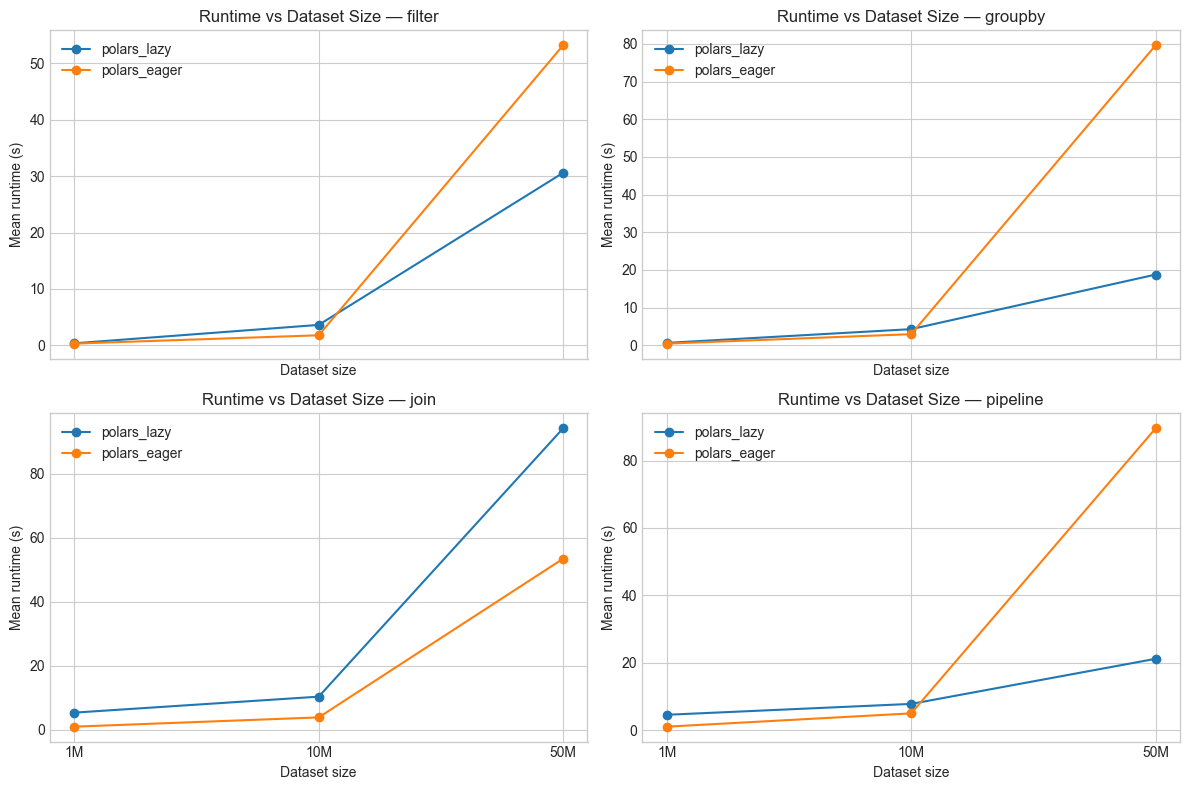

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, workload in zip(axes.ravel(), WORKLOAD_ORDER):
    subset = summary_by_size[summary_by_size["workload"].astype(str) == workload]
    for framework_group in FRAMEWORK_ORDER:
        line = subset[subset["framework_group"].astype(str) == framework_group].set_index("dataset_size").reindex(ROW_ORDER)
        ax.plot(ROW_ORDER, line["mean_runtime"], marker="o", label=framework_group)
    ax.set_title(f"Runtime vs Dataset Size — {workload}")
    ax.set_ylabel("Mean runtime (s)")
    ax.set_xlabel("Dataset size")
    ax.legend()
save_current_figure("runtime_vs_size_separate_workloads.png")
plt.show()


### Nhận xét

Biểu đồ cho thấy runtime của cả Lazy và Eager đều tăng khi dataset size tăng từ `1M` lên `50M`, nhưng tốc độ tăng khác nhau rõ theo từng workload. Nhìn chung, Lazy có xu hướng scale tốt hơn Eager ở một số workload lớn, đặc biệt là `groupby` và `pipeline`.

Ở `filter`, Eager nhanh hơn Lazy ở `1M` và `10M`, nhưng runtime của Eager tăng rất mạnh ở `50M`. Tại `50M`, Lazy trở thành lựa chọn nhanh hơn. Điều này cho thấy với filter, Lazy chỉ bắt đầu có lợi thế khi dữ liệu đủ lớn.

Ở `groupby`, Lazy và Eager khá gần nhau ở `1M` và `10M`, nhưng khi tăng lên `50M`, Eager tăng runtime rất mạnh trong khi Lazy tăng chậm hơn nhiều. Đây là một trong những bằng chứng rõ nhất cho thấy Lazy scale tốt hơn với aggregation trên dữ liệu lớn.

Ở `join`, Eager nhanh hơn Lazy ở cả ba kích thước dữ liệu. Dù Lazy cũng cải thiện tương đối khi dataset lớn hơn, runtime tuyệt đối của Lazy vẫn cao hơn Eager. Vì vậy, trong benchmark này, `join` là workload mà Eager có lợi thế ổn định nhất.

Ở `pipeline`, Eager nhanh hơn ở `1M` và `10M`, nhưng runtime tăng đột biến ở `50M`. Ngược lại, Lazy tăng chậm hơn và trở thành lựa chọn nhanh hơn rõ rệt ở dataset lớn. Điều này cho thấy Lazy phù hợp hơn với pipeline lớn, nơi optimizer có thể tối ưu nhiều bước xử lý trước khi thực thi.

Tóm lại, dataset size ảnh hưởng mạnh đến kết luận Lazy vs Eager. Lazy không phải lúc nào cũng nhanh hơn ở dataset nhỏ, nhưng khi dữ liệu tăng lên `50M`, Lazy thể hiện lợi thế rõ ở `filter`, `groupby`, và `pipeline`. Riêng với `join`, Eager vẫn là lựa chọn tốt hơn trong toàn bộ phạm vi benchmark.

## 11. Workload-Specific Interpretation

Phần này diễn giải theo workload. Vì benchmark là end-to-end, runtime gồm scan/read, scheduling/optimization, memory allocation, và materialization; không nên diễn giải như pure operator speed.


In [54]:
workload_interpretation = mean_speedup_by_workload.merge(
    mean_memory_ratio_by_workload,
    on="workload",
    how="left",
)

notes = {
    "filter": "Lazy can benefit from predicate/projection pushdown, but eager may be competitive when plan overhead dominates or output materialization is similar.",
    "groupby": "Lazy can reduce scan/projection work, while aggregation state and key cardinality remain major bottlenecks.",
    "join": "Eager can be competitive when lazy optimization overhead does not offset join materialization and key-handling costs.",
    "pipeline": "Lazy is often expected to benefit most because the optimizer can view the whole query plan and avoid unnecessary intermediates.",
}
workload_interpretation["interpretation_note"] = workload_interpretation["workload"].astype(str).map(notes)
workload_interpretation = workload_interpretation.sort_values("mean_lazy_speedup", ascending=False)

save_table(workload_interpretation, "polars_lazy_vs_eager_workload_interpretation.csv")
workload_interpretation


Saved results\table\polars_lazy_vs_eager_workload_interpretation.csv


,workload,mean_lazy_speedup,min_lazy_speedup,max_lazy_speedup,n_dataset_sizes_x,overall_faster_mode,mean_lazy_memory_ratio,min_lazy_memory_ratio,max_lazy_memory_ratio,n_dataset_sizes_y,overall_lower_memory_mode,interpretation_note
0,groupby,1.876511,0.688052,4.244854,3,Lazy,1.328612,0.919932,1.711144,3,Eager,"Lazy can reduce scan/projection work, while ag..."
1,pipeline,1.698375,0.226178,4.229776,3,Lazy,1.224528,1.076669,1.452701,3,Eager,Lazy is often expected to benefit most because...
2,filter,1.029103,0.493472,1.738967,3,Similar,1.079331,0.768244,1.568566,3,Eager,Lazy can benefit from predicate/projection pus...
3,join,0.369535,0.171209,0.567255,3,Eager,1.240869,0.967946,1.689757,3,Eager,Eager can be competitive when lazy optimizatio...


### Nhận xét

Bảng workload-specific interpretation cho thấy kết quả benchmark cần được hiểu theo từng workload, thay vì kết luận chung rằng Lazy luôn tốt hơn hoặc Eager luôn tốt hơn. Vì benchmark là end-to-end, runtime không chỉ phản ánh tốc độ của một operator riêng lẻ, mà còn bao gồm chi phí đọc dữ liệu, lập kế hoạch thực thi, scheduling, cấp phát bộ nhớ và materialization.

Với `groupby`, Lazy có lợi thế runtime trung bình rõ nhất, với `mean_lazy_speedup ≈ 1.88x` và `max_lazy_speedup ≈ 4.24x`. Tuy nhiên, `mean_lazy_memory_ratio ≈ 1.33x`, nghĩa là Lazy dùng nhiều peak memory hơn Eager khi xét trung bình. Điều này cho thấy Lazy có thể giúp cải thiện tốc độ aggregation trên dữ liệu lớn, nhưng lợi thế runtime đi kèm với chi phí memory cao hơn.

Với `pipeline`, Lazy cũng có lợi thế runtime đáng kể, với `mean_lazy_speedup ≈ 1.70x` và `max_lazy_speedup ≈ 4.23x`. Đây là workload phù hợp với Lazy vì pipeline nhiều bước thường tạo nhiều cơ hội cho optimizer, chẳng hạn như predicate pushdown, projection pruning hoặc giảm số bước materialization trung gian. Tuy nhiên, Lazy vẫn dùng nhiều memory hơn Eager trong cả ba dataset size, nên không thể kết luận Lazy tốt hơn toàn diện.

Với `filter`, kết quả gần cân bằng hơn. `mean_lazy_speedup ≈ 1.03x`, nên workload này được xem là `Similar` về runtime. Lazy có thể nhanh hơn ở dataset lớn, nhưng không có lợi thế ổn định ở mọi kích thước dữ liệu. Về memory, Eager vẫn tốt hơn khi xét trung bình, dù Lazy có thể dùng ít memory hơn ở một số size nhỏ hoặc trung bình.

Với `join`, Eager là lựa chọn tốt hơn cả về runtime và memory. `mean_lazy_speedup ≈ 0.37x` cho thấy Lazy chậm hơn rõ rệt, đồng thời `mean_lazy_memory_ratio ≈ 1.24x` cho thấy Lazy cũng dùng nhiều peak memory hơn. Trong benchmark này, Lazy optimization không đủ để bù lại overhead hoặc chi phí thực thi của join.

Tóm lại, Lazy có lợi thế rõ nhất ở `groupby` và `pipeline`, gần tương đương Eager ở `filter`, nhưng kém hơn Eager ở `join`. Tuy nhiên, các kết quả này nên được diễn giải như hiệu năng end-to-end của toàn bộ workload, không phải tốc độ thuần của từng operator riêng lẻ.

### 11.1 Filter: predicate/projection pushdown

`Filter` có thể hưởng lợi từ Lazy execution nếu predicate pushdown hoặc projection pruning giúp giảm lượng dữ liệu cần scan hoặc giảm số cột cần xử lý. Tuy nhiên, kết quả benchmark cho thấy lợi ích này không ổn định ở mọi dataset size.

Trong benchmark này, Eager nhanh hơn ở dataset nhỏ và trung bình, còn Lazy chỉ bắt đầu nhanh hơn ở `50M`. Điều này cho thấy với thao tác filter đơn giản, chi phí lập kế hoạch của Lazy có thể chưa đáng kể ở quy mô nhỏ. Lazy chỉ phát huy lợi thế khi dữ liệu đủ lớn để lợi ích từ scan-level optimization bù lại chi phí planning và materialization.

### 11.2 GroupBy: aggregation optimization

`GroupBy` là một trong những workload mà Lazy có lợi thế runtime rõ nhất, đặc biệt ở `50M`. Lazy có thể hưởng lợi từ projection pruning hoặc scan optimization trước bước aggregation, từ đó giảm bớt lượng dữ liệu không cần thiết trước khi xây dựng aggregation state.

Tuy nhiên, kết quả này không nên được hiểu là tốc độ thuần của riêng operator aggregation. Hiệu năng của `GroupBy` vẫn bị ảnh hưởng bởi key cardinality, chi phí xây dựng hash table, kích thước aggregation state, memory allocation và final materialization. Benchmark này đo hiệu năng end-to-end của toàn workload, không chỉ riêng bước aggregation.

### 11.3 Join: Eager may be competitive

`Join` là workload rõ nhất mà Eager vượt Lazy trong benchmark này. Lazy chậm hơn Eager ở cả ba dataset size và cũng dùng nhiều peak memory hơn khi xét trung bình.

Điều này cho thấy overhead hoặc execution plan của Lazy không đủ để bù lại chi phí chính của join trong workload này. Hiệu năng `Join` thường bị chi phối bởi key handling, join output size, memory allocation và materialization cost. Vì vậy, Eager có thể tương đương hoặc nhanh hơn Lazy khi Lazy optimization không giảm được đủ lượng công việc trước bước join.

### 11.4 Pipeline: query-plan optimization advantage

`Pipeline` là workload mà Lazy thường có lợi thế về mặt lý thuyết, vì optimizer có thể nhìn toàn bộ query plan trước khi thực thi. Điều này cho phép Lazy kết hợp nhiều operation, đẩy filter lên sớm hơn, loại bỏ các cột không cần thiết và tránh intermediate materialization không cần thiết.

Kết quả benchmark ủng hộ kỳ vọng này ở dataset lớn. Lazy chậm hơn ở dataset nhỏ, nhưng nhanh hơn rất rõ tại `50M`. Điều này cho thấy query-plan optimization của Lazy trở nên có giá trị hơn khi pipeline đủ lớn để lợi ích tối ưu hóa vượt qua chi phí planning ban đầu.

## 12. Supporting Evidence: Size, Stress, and Colab

Supporting groups are not mixed into the main lazy-vs-eager ranking. Section này chỉ dùng để xem Lazy/Eager behavior có ổn định dưới memory pressure, high-cardinality/skew, hoặc constrained runtime không.


In [55]:
def lazy_eager_ratio_for_group(df_ok, group_label):
    if df_ok.empty:
        return pd.DataFrame()
    summary = (
        df_ok
        .groupby(["workload", "dataset_size", "framework_group"], observed=True)
        .agg(
            mean_runtime=("runtime_sec", "mean"),
            mean_memory=("peak_memory_mb", "mean"),
            n_runs=("runtime_sec", "count"),
        )
        .reset_index()
    )
    runtime = summary.pivot_table(
        index=["workload", "dataset_size"],
        columns="framework_group",
        values="mean_runtime",
        observed=True,
    ).reset_index().rename_axis(None, axis=1)
    memory = summary.pivot_table(
        index=["workload", "dataset_size"],
        columns="framework_group",
        values="mean_memory",
        observed=True,
    ).reset_index().rename_axis(None, axis=1)
    out = runtime.merge(memory, on=["workload", "dataset_size"], suffixes=("_runtime", "_memory"))
    if {"polars_lazy_runtime", "polars_eager_runtime"}.issubset(out.columns):
        out["lazy_speedup"] = out["polars_eager_runtime"] / out["polars_lazy_runtime"]
    if {"polars_lazy_memory", "polars_eager_memory"}.issubset(out.columns):
        out["lazy_memory_ratio"] = out["polars_lazy_memory"] / out["polars_eager_memory"]
    out["support_group"] = group_label
    return out

support_size_ratio = lazy_eager_ratio_for_group(df_size_ok, "physical_scaling")
support_stress_ratio = lazy_eager_ratio_for_group(df_stress_ok, "synthetic_stress")
support_colab_ratio = lazy_eager_ratio_for_group(df_colab_ok, "colab_environment")

support_ratios = pd.concat([support_size_ratio, support_stress_ratio, support_colab_ratio], ignore_index=True)
if not support_ratios.empty:
    save_table(support_ratios, "polars_lazy_vs_eager_supporting_ratios.csv")
support_ratios


Saved results\table\polars_lazy_vs_eager_supporting_ratios.csv


,workload,dataset_size,polars_lazy_runtime,polars_eager_runtime,polars_lazy_memory,polars_eager_memory,lazy_speedup,lazy_memory_ratio,support_group
0,filter,10GB,3.622767,2.753367,5149.633333,6539.640000,0.760018,0.787449,physical_scaling
1,filter,20GB,8.287867,8.020333,9754.466667,12039.570000,0.967720,0.810201,physical_scaling
2,filter,5GB,2.634967,1.153267,2799.253333,3287.260000,0.437678,0.851546,physical_scaling
3,groupby,10GB,3.042333,4.062367,3654.276667,7756.950000,1.335280,0.471097,physical_scaling
4,groupby,20GB,4.890867,14.961767,3627.930000,11675.796667,3.059124,0.310722,physical_scaling
5,groupby,5GB,2.056033,1.739300,2639.486667,3747.183333,0.845949,0.704392,physical_scaling
6,join,10GB,9.442300,3.427733,7978.210000,7702.490000,0.363019,1.035796,physical_scaling
7,join,20GB,28.766467,11.129133,10645.800000,12370.653333,0.386879,0.860569,physical_scaling
8,join,5GB,6.302067,1.751267,4691.296667,4582.300000,0.277888,1.023786,physical_scaling
9,pipeline,10GB,6.450467,4.821767,4291.353333,8114.060000,0.747507,0.528879,physical_scaling


### Nhận xét

Bảng supporting evidence cho thấy các nhóm `physical_scaling`, `synthetic_stress`, và `colab_environment` có kết quả khác với main benchmark, nên không nên trộn trực tiếp vào bảng xếp hạng Lazy vs Eager chính. Các nhóm này phù hợp hơn để kiểm tra xem hành vi của Lazy và Eager có ổn định khi thay đổi điều kiện chạy, kích thước vật lý, high-cardinality/skew, hoặc môi trường bị giới hạn tài nguyên hay không. :contentReference[oaicite:0]{index=0}

Ở nhóm `physical_scaling`, Lazy không luôn nhanh hơn Eager, nhưng có lợi thế rõ trong một số workload lớn. Ví dụ, `groupby 20GB` đạt `lazy_speedup ≈ 3.06x`, và `pipeline 20GB` đạt `lazy_speedup ≈ 2.72x`. Đồng thời, Lazy thường dùng ít memory hơn Eager trong nhóm này, đặc biệt ở `groupby` và `pipeline`, nơi `lazy_memory_ratio` thấp hơn `1.0` khá rõ. Điều này cho thấy trong một số kịch bản scaling theo dung lượng dữ liệu, Lazy có thể giúp giảm memory pressure tốt hơn so với main benchmark.

Ở nhóm `synthetic_stress`, kết quả phụ thuộc mạnh vào kiểu dữ liệu stress. Với `10M_highuid`, Lazy thường chậm hơn Eager, đặc biệt ở `join`. Tuy nhiên, với `10M_skewed`, `groupby` lại là trường hợp Lazy thắng rất mạnh, với `lazy_speedup ≈ 4.29x` và `lazy_memory_ratio ≈ 0.22`. Điều này cho thấy phân phối key và cardinality có ảnh hưởng lớn đến hiệu năng, đặc biệt với các workload aggregation và join.

Ở nhóm `colab_environment`, Lazy có kết quả tốt hơn ở một số workload như `groupby` và `pipeline`, nhưng vẫn không thắng nhất quán ở tất cả trường hợp. Ví dụ, `pipeline 10M` có `lazy_speedup ≈ 1.45x` và dùng ít memory hơn Eager, trong khi `join` vẫn nghiêng về Eager về runtime. Điều này phù hợp với kết quả main benchmark: Lazy có thể có lợi ở pipeline hoặc aggregation, nhưng join vẫn là workload khó để Lazy vượt Eager.

Tóm lại, supporting evidence củng cố kết luận chính rằng Lazy không phải lúc nào cũng nhanh hơn Eager. Tuy nhiên, các nhóm hỗ trợ cũng cho thấy Lazy có thể có lợi hơn trong một số điều kiện cụ thể, đặc biệt khi workload là `groupby` hoặc `pipeline`, dữ liệu lớn hơn, hoặc môi trường có memory pressure. Vì vậy, kết luận chính nên dựa trên main benchmark, còn supporting groups nên được dùng như bằng chứng bổ sung về tính ổn định và giới hạn của kết quả.

### 12.1 Physical Scaling / Memory Pressure

Size results dùng để xem Lazy có giúp memory pressure không khi physical dataset size thay đổi. Không dùng nhóm này để thay thế ranking chính vì primary variable là physical size, không phải row count.

Subsection này kiểm tra ba ý:

- Lazy/Eager runtime ratio có thay đổi khi physical size tăng từ `5GB` lên `20GB` không?
- Lazy có giảm peak memory dưới memory pressure không?
- Supporting result này có cùng hướng với main real row-scaling result không?


In [72]:
SUPPORT_SIZE_ORDER = ["5GB", "10GB", "20GB"]
SUPPORT_STRESS_ORDER = ["10M_skewed", "10M_highuid"]
SUPPORT_COLAB_ORDER = ["1M", "10M"]


def classify_speedup(value, threshold=1.05):
    if pd.isna(value):
        return "Unknown"
    if value > threshold:
        return "Lazy faster"
    if value < 1 / threshold:
        return "Eager faster"
    return "Similar"


def classify_memory(value, threshold=1.05):
    if pd.isna(value):
        return "Unknown"
    if value < 1 / threshold:
        return "Lazy lower memory"
    if value > threshold:
        return "Eager lower memory"
    return "Similar"


def ordered_support(ratio_df, size_order):
    out = ratio_df.copy()
    out["workload"] = pd.Categorical(out["workload"].astype(str), categories=WORKLOAD_ORDER, ordered=True)
    out["dataset_size"] = pd.Categorical(out["dataset_size"].astype(str), categories=size_order, ordered=True)
    return out.sort_values(["workload", "dataset_size"])


def support_summary(ratio_df, group_label):
    if ratio_df.empty:
        return pd.DataFrame()
    out = (
        ratio_df
        .groupby("workload", observed=True)
        .agg(
            mean_lazy_speedup=("lazy_speedup", "mean"),
            min_lazy_speedup=("lazy_speedup", "min"),
            max_lazy_speedup=("lazy_speedup", "max"),
            mean_lazy_memory_ratio=("lazy_memory_ratio", "mean"),
            min_lazy_memory_ratio=("lazy_memory_ratio", "min"),
            max_lazy_memory_ratio=("lazy_memory_ratio", "max"),
            n_points=("lazy_speedup", "count"),
        )
        .reset_index()
    )
    out["support_group"] = group_label
    out["runtime_reading"] = out["mean_lazy_speedup"].map(classify_speedup)
    out["memory_reading"] = out["mean_lazy_memory_ratio"].map(classify_memory)
    return out


def support_size_change(ratio_df, size_order, group_label):
    if ratio_df.empty:
        return pd.DataFrame()
    rows = []
    ordered = ordered_support(ratio_df, size_order)
    for workload, part in ordered.groupby("workload", observed=True):
        part = part.dropna(subset=["lazy_speedup", "lazy_memory_ratio"])
        if part.empty:
            continue
        first = part.iloc[0]
        last = part.iloc[-1]
        rows.append({
            "support_group": group_label,
            "workload": str(workload),
            "first_size": str(first["dataset_size"]),
            "last_size": str(last["dataset_size"]),
            "speedup_first": first["lazy_speedup"],
            "speedup_last": last["lazy_speedup"],
            "speedup_change_last_minus_first": last["lazy_speedup"] - first["lazy_speedup"],
            "memory_ratio_first": first["lazy_memory_ratio"],
            "memory_ratio_last": last["lazy_memory_ratio"],
            "memory_ratio_change_last_minus_first": last["lazy_memory_ratio"] - first["lazy_memory_ratio"],
        })
    return pd.DataFrame(rows)


def plot_support_ratios(ratio_df, title, size_order, filename):
    if ratio_df.empty:
        print(f"No rows available for {title}.")
        return
    plot_df = ordered_support(ratio_df, size_order).copy()
    labels = plot_df["workload"].astype(str) + "\n" + plot_df["dataset_size"].astype(str)
    x = np.arange(len(plot_df))

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axes[0].bar(x, plot_df["lazy_speedup"], color="#2a9d8f")
    axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
    axes[0].set_ylabel("Eager runtime / Lazy runtime")
    axes[0].set_title(f"{title} — Lazy Speedup")

    axes[1].bar(x, plot_df["lazy_memory_ratio"], color="#457b9d")
    axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)
    axes[1].set_ylabel("Lazy memory / Eager memory")
    axes[1].set_title(f"{title} — Lazy Memory Ratio")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=45, ha="right")

    save_current_figure(filename)
    plt.show()

In [57]:
physical_ratio = ordered_support(support_size_ratio, SUPPORT_SIZE_ORDER)
physical_summary = support_summary(physical_ratio, "physical_scaling")
physical_change = support_size_change(physical_ratio, SUPPORT_SIZE_ORDER, "physical_scaling")
physical_largest_size = (
    physical_ratio[physical_ratio["dataset_size"].astype(str) == SUPPORT_SIZE_ORDER[-1]]
    .copy()
    .sort_values("workload")
)

save_table(physical_ratio, "polars_lazy_vs_eager_physical_scaling_ratios.csv")
save_table(physical_summary, "polars_lazy_vs_eager_physical_scaling_summary.csv")
save_table(physical_change, "polars_lazy_vs_eager_physical_scaling_size_change.csv")
save_table(physical_largest_size, "polars_lazy_vs_eager_physical_scaling_largest_size.csv")

physical_summary


Saved results\table\polars_lazy_vs_eager_physical_scaling_ratios.csv
Saved results\table\polars_lazy_vs_eager_physical_scaling_summary.csv
Saved results\table\polars_lazy_vs_eager_physical_scaling_size_change.csv
Saved results\table\polars_lazy_vs_eager_physical_scaling_largest_size.csv


,workload,mean_lazy_speedup,min_lazy_speedup,max_lazy_speedup,mean_lazy_memory_ratio,min_lazy_memory_ratio,max_lazy_memory_ratio,n_points,support_group,runtime_reading,memory_reading
0,filter,0.721805,0.437678,0.967720,0.816399,0.787449,0.851546,3,physical_scaling,Eager faster,Lazy lower memory
1,groupby,1.746784,0.845949,3.059124,0.495404,0.310722,0.704392,3,physical_scaling,Lazy faster,Lazy lower memory
2,join,0.342595,0.277888,0.386879,0.973384,0.860569,1.035796,3,physical_scaling,Eager faster,Similar
3,pipeline,1.312692,0.467935,2.722633,0.610949,0.466635,0.837335,3,physical_scaling,Lazy faster,Lazy lower memory


### Nhận xét

Kết quả `physical_scaling` cho thấy Lazy có xu hướng hỗ trợ memory pressure tốt hơn so với main row-scaling benchmark. Ở cả `filter`, `groupby`, và `pipeline`, `mean_lazy_memory_ratio < 1.0`, nghĩa là Lazy dùng ít peak memory hơn Eager khi physical dataset size thay đổi từ `5GB` đến `20GB`. Riêng `join` có memory ratio trung bình gần `1.0`, nên được xem là gần tương đương.

Về runtime, kết quả vẫn phụ thuộc vào workload. `groupby` và `pipeline` có `mean_lazy_speedup > 1.0`, lần lượt khoảng `1.75x` và `1.31x`, cho thấy Lazy nhanh hơn trung bình trong hai workload này. Ngược lại, `filter` và `join` có `mean_lazy_speedup < 1.0`, nên Eager vẫn nhanh hơn về runtime.

Khi physical size tăng, Lazy thể hiện lợi thế rõ nhất ở các workload có nhiều cơ hội tối ưu query plan như `groupby` và `pipeline`. Với `groupby`, speedup cao nhất đạt khoảng `3.06x`; với `pipeline`, speedup cao nhất đạt khoảng `2.72x`. Điều này cho thấy Lazy có thể phát huy hiệu quả tốt hơn trong các workload lớn hoặc chịu memory pressure cao.

So với main real row-scaling result, supporting result này có cùng hướng về runtime ở một số điểm: Lazy vẫn có lợi hơn với `groupby` và `pipeline`, còn Eager vẫn mạnh hơn ở `join`. Tuy nhiên, hướng memory lại khác đáng chú ý. Trong main benchmark, Eager thường có peak memory thấp hơn trung bình, trong khi ở physical scaling, Lazy lại dùng ít memory hơn ở hầu hết workload. Điều này cho thấy memory behavior phụ thuộc mạnh vào cách dataset scale: theo row count hay theo physical size.

Tóm lại, nhóm `physical_scaling` không thay thế ranking chính, nhưng cung cấp bằng chứng hỗ trợ rằng Lazy có thể hữu ích hơn dưới memory pressure, đặc biệt ở `groupby` và `pipeline`. Tuy nhiên, với `join`, Eager vẫn là lựa chọn ổn định hơn về runtime.

In [ ]:
physical_change

,support_group,workload,first_size,last_size,speedup_first,speedup_last,speedup_change_last_minus_first,memory_ratio_first,memory_ratio_last,memory_ratio_change_last_minus_first
0,physical_scaling,filter,5GB,20GB,0.437678,0.967720,0.530042,0.851546,0.810201,-0.041345
1,physical_scaling,groupby,5GB,20GB,0.845949,3.059124,2.213174,0.704392,0.310722,-0.393670
2,physical_scaling,join,5GB,20GB,0.277888,0.386879,0.108991,1.023786,0.860569,-0.163218
3,physical_scaling,pipeline,5GB,20GB,0.467935,2.722633,2.254699,0.837335,0.466635,-0.370700


### Nhận xét

Bảng này cho thấy khi physical dataset size tăng từ `5GB` lên `20GB`, Lazy trở nên cạnh tranh hơn so với Eager ở tất cả workload. Cả bốn workload đều có `speedup_change_last_minus_first > 0`, nghĩa là `lazy_speedup` tăng khi dữ liệu vật lý lớn hơn.

Mức cải thiện runtime rõ nhất xuất hiện ở `pipeline` và `groupby`. Với `pipeline`, speedup tăng từ khoảng `0.47x` ở `5GB` lên `2.72x` ở `20GB`. Với `groupby`, speedup tăng từ khoảng `0.85x` lên `3.06x`. Điều này cho thấy Lazy phát huy lợi thế mạnh hơn khi physical dataset size lớn, đặc biệt ở các workload có nhiều cơ hội query-plan optimization hoặc scan optimization.

`filter` cũng cải thiện từ `0.44x` lên `0.97x`, nghĩa là Lazy vẫn chưa vượt Eager ở `20GB`, nhưng đã gần tương đương hơn nhiều so với `5GB`. `join` có cải thiện nhẹ từ `0.28x` lên `0.39x`, nhưng vẫn thấp hơn `1.0`, nên Eager vẫn nhanh hơn rõ trong workload này.

Về memory, tất cả workload đều có `memory_ratio_change_last_minus_first < 0`, nghĩa là Lazy dùng ít memory hơn tương đối khi physical size tăng. Mức cải thiện memory rõ nhất nằm ở `groupby` và `pipeline`, nơi memory ratio giảm mạnh từ `5GB` lên `20GB`. Điều này cho thấy Lazy có khả năng giảm memory pressure tốt hơn khi dữ liệu vật lý lớn hơn, đặc biệt với workload aggregation và pipeline.

Tóm lại, physical scaling result cho thấy khi dữ liệu tăng từ `5GB` lên `20GB`, Lazy vừa cải thiện tương đối về runtime, vừa cải thiện tương đối về memory. Tuy nhiên, lợi thế runtime chỉ thật sự rõ ở `groupby` và `pipeline`; với `join`, Eager vẫn là lựa chọn nhanh hơn.

In [59]:
physical_largest_size[[
    "workload", "dataset_size", "polars_lazy_runtime", "polars_eager_runtime",
    "lazy_speedup", "polars_lazy_memory", "polars_eager_memory", "lazy_memory_ratio"
]]


,workload,dataset_size,polars_lazy_runtime,polars_eager_runtime,lazy_speedup,polars_lazy_memory,polars_eager_memory,lazy_memory_ratio
1,filter,20GB,8.287867,8.020333,0.967720,9754.466667,12039.570000,0.810201
4,groupby,20GB,4.890867,14.961767,3.059124,3627.930000,11675.796667,0.310722
7,join,20GB,28.766467,11.129133,0.386879,10645.800000,12370.653333,0.860569
10,pipeline,20GB,8.442733,22.986467,2.722633,4724.210000,10123.996667,0.466635


### Nhận xét

Ở mức physical size `20GB`, Lazy cho thấy lợi thế rõ về memory ở tất cả workload. Tất cả các giá trị `lazy_memory_ratio` đều nhỏ hơn `1.0`, nghĩa là Lazy dùng ít peak memory hơn Eager trong toàn bộ các workload được kiểm tra.

Về runtime, Lazy nhanh hơn rõ ở `groupby` và `pipeline`. Với `groupby`, Lazy đạt speedup khoảng `3.06x`, đồng thời chỉ dùng khoảng `31%` peak memory so với Eager. Với `pipeline`, Lazy đạt speedup khoảng `2.72x` và dùng khoảng `47%` peak memory so với Eager. Đây là hai trường hợp cho thấy Lazy vừa nhanh hơn vừa tiết kiệm memory hơn khi physical dataset size lớn.

Ở `filter`, Lazy gần tương đương Eager về runtime, với `lazy_speedup ≈ 0.97x`, nhưng lại dùng ít memory hơn đáng kể (`lazy_memory_ratio ≈ 0.81`). Điều này cho thấy dù Lazy chưa nhanh hơn Eager ở filter 20GB, nó vẫn có lợi thế về memory pressure.

Với `join`, Lazy vẫn chậm hơn Eager khá rõ, với `lazy_speedup ≈ 0.39x`. Tuy nhiên, Lazy lại dùng ít peak memory hơn, với `lazy_memory_ratio ≈ 0.86`. Vì vậy, trong điều kiện physical size lớn, join vẫn nghiêng về Eager nếu ưu tiên runtime, nhưng Lazy có thể hữu ích hơn nếu memory là ràng buộc chính.

Tóm lại, tại `20GB`, Lazy thể hiện lợi thế memory nhất quán và lợi thế runtime mạnh ở `groupby` và `pipeline`. Kết quả này củng cố nhận định rằng Lazy có thể hữu ích hơn dưới memory pressure, nhưng không đảm bảo nhanh hơn ở mọi workload, đặc biệt là `join`.

Saved results\figures\notebook_07_lazy_vs_eager_polars\support_physical_scaling_ratios.png


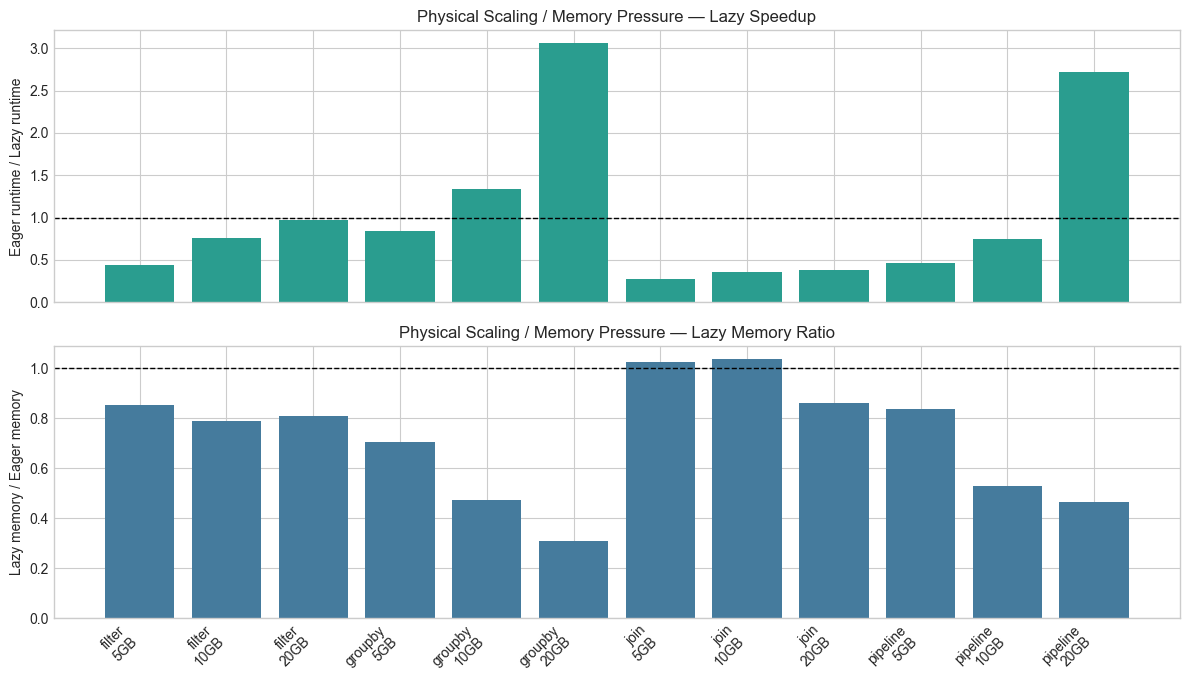

In [60]:
plot_support_ratios(
    physical_ratio,
    "Physical Scaling / Memory Pressure",
    SUPPORT_SIZE_ORDER,
    "support_physical_scaling_ratios.png",
)


### Nhận xét

Biểu đồ physical scaling cho thấy Lazy có xu hướng cải thiện khi physical dataset size tăng, đặc biệt ở `groupby` và `pipeline`. Đường ngang tại `1.0` trong biểu đồ speedup là mốc so sánh: giá trị lớn hơn `1.0` nghĩa là Lazy nhanh hơn, còn nhỏ hơn `1.0` nghĩa là Eager nhanh hơn.

Ở biểu đồ speedup, `groupby` và `pipeline` là hai workload có lợi thế Lazy rõ nhất khi size tăng lên `20GB`. `groupby 20GB` đạt speedup trên `3.0x`, còn `pipeline 20GB` đạt khoảng `2.7x`. Điều này cho thấy Lazy có thể phát huy tốt hơn dưới điều kiện dữ liệu lớn hoặc memory pressure, đặc biệt với các workload có nhiều cơ hội tối ưu query plan.

`filter` cải thiện dần khi size tăng từ `5GB` lên `20GB`, nhưng vẫn nằm dưới mốc `1.0`, nghĩa là Eager vẫn nhanh hơn hoặc gần tương đương. `join` cũng luôn nằm dưới `1.0`, cho thấy Eager vẫn nhanh hơn Lazy về runtime trong workload này.

Ở biểu đồ memory ratio, hầu hết các cột đều nằm dưới `1.0`, nghĩa là Lazy dùng ít peak memory hơn Eager trong phần lớn trường hợp physical scaling. Lợi thế memory rõ nhất xuất hiện ở `groupby 20GB` và `pipeline 20GB`, nơi Lazy chỉ dùng một phần nhỏ peak memory so với Eager.

Tóm lại, supporting result này cho thấy Lazy có thể hữu ích hơn dưới memory pressure, đặc biệt ở `groupby` và `pipeline`, vì vừa cải thiện runtime ở size lớn vừa giảm peak memory. Tuy nhiên, kết quả này không thay thế ranking chính, vì nhóm này scale theo physical dataset size thay vì row count. Với `join`, Eager vẫn là lựa chọn tốt hơn nếu ưu tiên runtime.

### 12.2 Synthetic Stress: High UID and Skew

Stress results dùng để xem Lazy-vs-Eager thay đổi thế nào khi key skew hoặc high cardinality tăng. Đây là edge-case behavior, không phải kết luận main real-data.

Subsection này tách rõ `10M_skewed` và `10M_highuid`, sau đó so sánh hướng kết quả với main real row-scaling summary theo workload.


In [61]:
stress_ratio = ordered_support(support_stress_ratio, SUPPORT_STRESS_ORDER)
stress_summary = support_summary(stress_ratio, "synthetic_stress")
stress_change = support_size_change(stress_ratio, SUPPORT_STRESS_ORDER, "synthetic_stress")

main_workload_baseline = mean_speedup_by_workload[["workload", "mean_lazy_speedup"]].merge(
    mean_memory_ratio_by_workload[["workload", "mean_lazy_memory_ratio"]],
    on="workload",
    how="left",
    suffixes=("_main", "_main"),
).rename(columns={
    "mean_lazy_speedup": "main_mean_lazy_speedup",
    "mean_lazy_memory_ratio": "main_mean_lazy_memory_ratio",
})

stress_vs_main = stress_summary.merge(main_workload_baseline, on="workload", how="left")
stress_vs_main["speedup_delta_vs_main"] = stress_vs_main["mean_lazy_speedup"] - stress_vs_main["main_mean_lazy_speedup"]
stress_vs_main["memory_ratio_delta_vs_main"] = stress_vs_main["mean_lazy_memory_ratio"] - stress_vs_main["main_mean_lazy_memory_ratio"]
stress_vs_main["stress_runtime_shift"] = stress_vs_main["speedup_delta_vs_main"].apply(
    lambda x: "Lazy advantage increases" if x > 0.10 else "Lazy advantage decreases" if x < -0.10 else "Similar to main"
)
stress_vs_main["stress_memory_shift"] = stress_vs_main["memory_ratio_delta_vs_main"].apply(
    lambda x: "Lazy memory ratio increases" if x > 0.10 else "Lazy memory ratio decreases" if x < -0.10 else "Similar to main"
)

save_table(stress_ratio, "polars_lazy_vs_eager_synthetic_stress_ratios.csv")
save_table(stress_summary, "polars_lazy_vs_eager_synthetic_stress_summary.csv")
save_table(stress_change, "polars_lazy_vs_eager_synthetic_stress_scenario_change.csv")
save_table(stress_vs_main, "polars_lazy_vs_eager_synthetic_stress_vs_main.csv")

stress_ratio


Saved results\table\polars_lazy_vs_eager_synthetic_stress_ratios.csv
Saved results\table\polars_lazy_vs_eager_synthetic_stress_summary.csv
Saved results\table\polars_lazy_vs_eager_synthetic_stress_scenario_change.csv
Saved results\table\polars_lazy_vs_eager_synthetic_stress_vs_main.csv


,workload,dataset_size,polars_lazy_runtime,polars_eager_runtime,polars_lazy_memory,polars_eager_memory,lazy_speedup,lazy_memory_ratio,support_group
1,filter,10M_skewed,2.414400,1.890767,3864.010000,4625.123333,0.783121,0.835439,synthetic_stress
0,filter,10M_highuid,4.910800,2.577333,3727.746667,4608.863333,0.524830,0.808821,synthetic_stress
3,groupby,10M_skewed,0.623667,2.673533,1176.986667,5328.640000,4.286799,0.220879,synthetic_stress
2,groupby,10M_highuid,6.969033,4.071133,2997.750000,5335.433333,0.584175,0.561857,synthetic_stress
5,join,10M_skewed,7.564100,2.817400,6117.653333,5793.983333,0.372470,1.055863,synthetic_stress
4,join,10M_highuid,21.882700,4.539467,5819.420000,5734.213333,0.207445,1.014859,synthetic_stress
7,pipeline,10M_skewed,5.106167,4.380700,2247.260000,5822.366667,0.857923,0.385970,synthetic_stress
6,pipeline,10M_highuid,9.916267,6.785600,3683.660000,5760.893333,0.684290,0.639425,synthetic_stress


### Nhận xét

Kết quả `synthetic_stress` cho thấy hành vi Lazy-vs-Eager thay đổi mạnh khi dữ liệu có `high UID` hoặc `skewed key distribution`. Vì đây là edge-case benchmark, kết quả này không nên được dùng thay cho kết luận chính trên real data, mà nên xem như bằng chứng bổ sung về độ nhạy của Lazy và Eager trong các điều kiện dữ liệu đặc biệt.

Với `10M_skewed`, `groupby` là trường hợp Lazy thắng rất rõ. Lazy đạt `lazy_speedup ≈ 4.29x` và `lazy_memory_ratio ≈ 0.22`, nghĩa là vừa nhanh hơn Eager nhiều lần, vừa dùng ít peak memory hơn đáng kể. Điều này cho thấy khi key distribution bị skew, Lazy có thể tận dụng execution plan tốt hơn hoặc giảm đáng kể lượng dữ liệu cần xử lý trước aggregation.

Ngược lại, với `10M_highuid`, `groupby` lại nghiêng về Eager về runtime, với `lazy_speedup ≈ 0.58x`. Tuy nhiên, Lazy vẫn dùng ít memory hơn Eager, với `lazy_memory_ratio ≈ 0.56`. Điều này cho thấy high cardinality có thể làm tăng chi phí aggregation state hoặc hash-table handling, khiến lợi thế runtime của Lazy không còn rõ như trong trường hợp skewed.

Với `filter`, Eager nhanh hơn Lazy ở cả `10M_skewed` và `10M_highuid`, vì `lazy_speedup` đều nhỏ hơn `1.0`. Tuy nhiên, Lazy lại dùng ít peak memory hơn trong cả hai trường hợp. Điều này cho thấy filter stress không tạo đủ lợi thế runtime cho Lazy, nhưng Lazy vẫn có thể giúp giảm memory usage.

Với `join`, Eager thắng rõ ở cả hai stress case. Lazy chậm hơn nhiều, đặc biệt ở `10M_highuid`, nơi `lazy_speedup ≈ 0.21x`. Memory ratio của join cũng lớn hơn `1.0`, nghĩa là Lazy dùng nhiều memory hơn Eager. Kết quả này cùng hướng với main benchmark: `join` là workload mà Eager ổn định hơn cả về runtime và memory.

Với `pipeline`, Eager vẫn nhanh hơn Lazy trong cả `skewed` và `highuid`, nhưng Lazy dùng ít memory hơn đáng kể. Điều này khác một phần so với main benchmark, nơi Lazy thắng runtime rõ ở `50M`. Sự khác biệt này cho thấy pipeline performance phụ thuộc mạnh vào đặc điểm dữ liệu, không chỉ phụ thuộc vào row count.

Tóm lại, stress benchmark cho thấy key distribution và cardinality có ảnh hưởng lớn đến kết quả Lazy-vs-Eager. Kết quả ổn định nhất là `join` vẫn nghiêng về Eager, còn `groupby` rất nhạy với phân phối key: Lazy thắng rất mạnh trong trường hợp `skewed`, nhưng không thắng runtime trong trường hợp `highuid`.

In [ ]:
stress_summary

,workload,mean_lazy_speedup,min_lazy_speedup,max_lazy_speedup,mean_lazy_memory_ratio,min_lazy_memory_ratio,max_lazy_memory_ratio,n_points,support_group,runtime_reading,memory_reading
0,filter,0.653975,0.524830,0.783121,0.822130,0.808821,0.835439,2,synthetic_stress,Eager faster,Lazy lower memory
1,groupby,2.435487,0.584175,4.286799,0.391368,0.220879,0.561857,2,synthetic_stress,Lazy faster,Lazy lower memory
2,join,0.289958,0.207445,0.372470,1.035361,1.014859,1.055863,2,synthetic_stress,Eager faster,Similar
3,pipeline,0.771107,0.684290,0.857923,0.512698,0.385970,0.639425,2,synthetic_stress,Eager faster,Lazy lower memory


### Nhận xét

Bảng summary `synthetic_stress` cho thấy Lazy và Eager phản ứng khác nhau rõ rệt khi dữ liệu có high cardinality hoặc key skew. Kết quả này không hoàn toàn giống main benchmark, nên chỉ nên dùng như supporting evidence cho edge-case behavior.

Về runtime, Lazy chỉ nhanh hơn Eager ở `groupby`, với `mean_lazy_speedup ≈ 2.44x`. Đây là workload duy nhất trong nhóm stress có `runtime_reading = Lazy faster`. Tuy nhiên, khoảng dao động rất lớn, từ `0.58x` đến `4.29x`, cho thấy kết quả `groupby` phụ thuộc mạnh vào kiểu stress: Lazy thắng rất mạnh trong trường hợp skewed nhưng không thắng trong trường hợp high UID.

Ở `filter`, `join`, và `pipeline`, Eager nhanh hơn Lazy về runtime vì `mean_lazy_speedup < 1.0`. Trong đó, `join` là workload mà Lazy kém nhất, với `mean_lazy_speedup ≈ 0.29x`. Điều này tiếp tục củng cố kết luận từ main benchmark rằng Eager ổn định hơn cho join.

Về memory, Lazy dùng ít peak memory hơn ở `filter`, `groupby`, và `pipeline`, với `mean_lazy_memory_ratio` đều nhỏ hơn `1.0`. Lợi thế memory rõ nhất nằm ở `groupby`, nơi Lazy chỉ dùng khoảng `39%` memory của Eager khi xét trung bình, và ở một stress case thấp nhất chỉ khoảng `22%`. Với `join`, memory ratio gần `1.0`, nên được xem là gần tương đương.

Tóm lại, stress benchmark cho thấy Lazy có thể giúp giảm memory trong nhiều edge cases, nhưng không đảm bảo nhanh hơn. Runtime benefit của Lazy chỉ thật sự rõ ở `groupby`, còn `join` tiếp tục là workload nghiêng về Eager.

In [ ]:
stress_vs_main[[
    "workload", "mean_lazy_speedup", "main_mean_lazy_speedup", "speedup_delta_vs_main", "stress_runtime_shift",
    "mean_lazy_memory_ratio", "main_mean_lazy_memory_ratio", "memory_ratio_delta_vs_main", "stress_memory_shift",
]]

,workload,mean_lazy_speedup,main_mean_lazy_speedup,speedup_delta_vs_main,stress_runtime_shift,mean_lazy_memory_ratio,main_mean_lazy_memory_ratio,memory_ratio_delta_vs_main,stress_memory_shift
0,filter,0.653975,1.029103,-0.375128,Lazy advantage decreases,0.822130,1.079331,-0.257201,Lazy memory ratio decreases
1,groupby,2.435487,1.876511,0.558976,Lazy advantage increases,0.391368,1.328612,-0.937244,Lazy memory ratio decreases
2,join,0.289958,0.369535,-0.079577,Similar to main,1.035361,1.240869,-0.205507,Lazy memory ratio decreases
3,pipeline,0.771107,1.698375,-0.927268,Lazy advantage decreases,0.512698,1.224528,-0.711831,Lazy memory ratio decreases


### Nhận xét

Bảng so sánh giữa `synthetic_stress` và main benchmark cho thấy stress data làm thay đổi đáng kể hành vi Lazy-vs-Eager, đặc biệt ở `filter`, `groupby`, và `pipeline`. Vì stress benchmark dùng dữ liệu high-cardinality hoặc skewed, kết quả này nên được xem là edge-case behavior chứ không thay thế kết luận chính từ real data.

Về runtime, `groupby` là workload duy nhất mà Lazy advantage tăng trong stress setting. Mean lazy speedup tăng từ khoảng `1.88x` ở main benchmark lên `2.44x` trong stress benchmark. Điều này cho thấy `groupby` rất nhạy với phân phối key, và Lazy có thể có lợi hơn khi dữ liệu skewed tạo điều kiện cho optimizer hoặc execution plan hoạt động hiệu quả hơn.

Ngược lại, `filter` và `pipeline` đều có Lazy advantage giảm. Với `filter`, mean speedup giảm từ khoảng `1.03x` xuống `0.65x`, nghĩa là stress data làm Eager nhanh hơn Lazy rõ hơn. Với `pipeline`, mean speedup giảm mạnh từ khoảng `1.70x` xuống `0.77x`, cho thấy lợi thế pipeline của Lazy trong main benchmark không ổn định khi chuyển sang highuid/skewed stress cases.

`join` có kết quả runtime khá giống main benchmark. Mean lazy speedup vẫn nhỏ hơn `1.0` và chỉ thay đổi nhẹ từ khoảng `0.37x` xuống `0.29x`. Điều này củng cố kết luận rằng `join` là workload nghiêng về Eager một cách tương đối ổn định, kể cả trong stress setting.

Về memory, tất cả workload đều có `memory_ratio_delta_vs_main < 0`, nghĩa là Lazy memory ratio giảm so với main benchmark. Nói cách khác, trong stress benchmark, Lazy dùng ít memory hơn tương đối so với Eager ở nhiều workload hơn. Sự cải thiện rõ nhất xuất hiện ở `groupby` và `pipeline`, nơi memory ratio giảm mạnh so với main result.

Tóm lại, synthetic stress làm Lazy có lợi hơn về memory, nhưng không nhất thiết có lợi hơn về runtime. `GroupBy` là trường hợp Lazy được cải thiện cả về runtime lẫn memory trong stress setting, còn `join` vẫn ổn định nghiêng về Eager. `Filter` và `pipeline` cho thấy Lazy advantage có thể giảm khi đặc điểm dữ liệu thay đổi.

Saved results\figures\notebook_07_lazy_vs_eager_polars\support_synthetic_stress_ratios.png


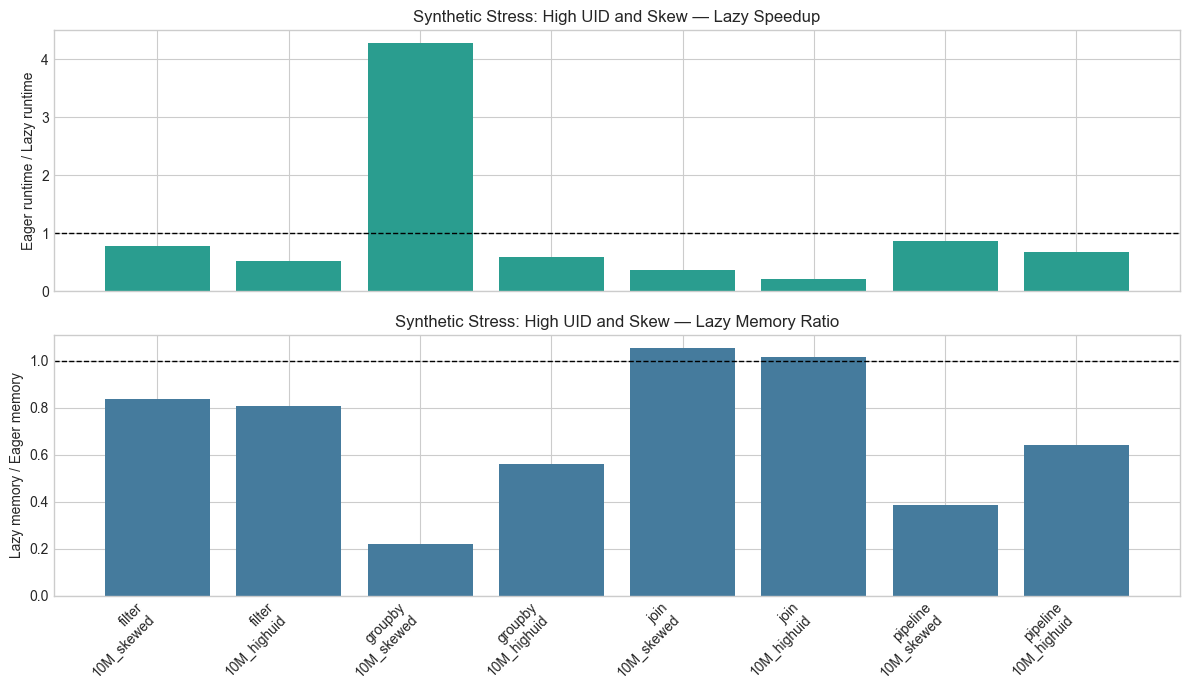

In [64]:
plot_support_ratios(
    stress_ratio,
    "Synthetic Stress: High UID and Skew",
    SUPPORT_STRESS_ORDER,
    "support_synthetic_stress_ratios.png",
)


### Nhận xét

Biểu đồ synthetic stress cho thấy Lazy-vs-Eager rất nhạy với đặc điểm phân phối dữ liệu, đặc biệt là `skew` và `high UID`. Đường ngang tại `1.0` là mốc so sánh: với speedup, giá trị lớn hơn `1.0` nghĩa là Lazy nhanh hơn; với memory ratio, giá trị nhỏ hơn `1.0` nghĩa là Lazy dùng ít memory hơn.

Ở biểu đồ speedup, chỉ có `groupby 10M_skewed` vượt xa mốc `1.0`, với Lazy nhanh hơn Eager hơn `4x`. Đây là trường hợp nổi bật nhất trong stress benchmark và cho thấy Lazy có thể phát huy lợi thế rất mạnh khi workload aggregation gặp dữ liệu skewed. Tuy nhiên, `groupby 10M_highuid` lại nằm dưới `1.0`, nghĩa là Lazy không thắng trong trường hợp high-cardinality. Điều này cho thấy hiệu năng `groupby` phụ thuộc mạnh vào phân phối key, không chỉ vào row count.

Các workload còn lại gồm `filter`, `join`, và `pipeline` đều có speedup dưới `1.0` trong cả hai stress case. Điều này nghĩa là Eager nhanh hơn Lazy về runtime trong các trường hợp này. Đặc biệt, `join` có speedup thấp nhất, tiếp tục củng cố kết luận rằng Eager ổn định hơn cho join.

Ở biểu đồ memory ratio, Lazy dùng ít memory hơn Eager trong hầu hết các trường hợp vì phần lớn giá trị nằm dưới `1.0`. Lợi thế memory rõ nhất nằm ở `groupby 10M_skewed` và `pipeline 10M_skewed`, nơi Lazy giảm peak memory rất mạnh so với Eager. Riêng `join` có memory ratio gần hoặc cao hơn `1.0`, cho thấy Lazy không có lợi thế memory rõ trong workload này.

Tóm lại, synthetic stress result cho thấy Lazy có thể giảm memory tốt hơn trong nhiều edge cases, nhưng runtime benefit không ổn định. Trường hợp đáng chú ý nhất là `groupby 10M_skewed`, nơi Lazy vừa nhanh hơn rất nhiều vừa dùng ít memory hơn. Ngược lại, với `join`, Eager vẫn là lựa chọn tốt hơn cả về runtime và gần như cả memory.

### 12.3 Colab / Environment Sensitivity

Colab results dùng để kiểm tra Lazy-vs-Eager có ổn định trong constrained runtime không. Nếu khác main results, diễn giải là environment sensitivity.

Subsection này so sánh Colab với main real row-scaling ở các dataset size cùng tồn tại (`1M`, `10M`). Mục tiêu không phải xếp hạng lại, mà là kiểm tra hướng speedup và memory ratio có đổi trong môi trường constrained hơn không.


In [65]:
colab_ratio = ordered_support(support_colab_ratio, SUPPORT_COLAB_ORDER)
colab_summary = support_summary(colab_ratio, "colab_environment")
colab_change = support_size_change(colab_ratio, SUPPORT_COLAB_ORDER, "colab_environment")

main_ratio_for_colab_sizes = speedup_by_size[["workload", "dataset_size", "lazy_speedup"]].merge(
    memory_ratio_by_size[["workload", "dataset_size", "lazy_memory_ratio"]],
    on=["workload", "dataset_size"],
    how="left",
).rename(columns={
    "lazy_speedup": "main_lazy_speedup",
    "lazy_memory_ratio": "main_lazy_memory_ratio",
})

colab_vs_main = colab_ratio[["workload", "dataset_size", "lazy_speedup", "lazy_memory_ratio"]].merge(
    main_ratio_for_colab_sizes,
    on=["workload", "dataset_size"],
    how="left",
)
colab_vs_main = colab_vs_main.rename(columns={
    "lazy_speedup": "colab_lazy_speedup",
    "lazy_memory_ratio": "colab_lazy_memory_ratio",
})
colab_vs_main["speedup_delta_colab_minus_main"] = colab_vs_main["colab_lazy_speedup"] - colab_vs_main["main_lazy_speedup"]
colab_vs_main["memory_ratio_delta_colab_minus_main"] = colab_vs_main["colab_lazy_memory_ratio"] - colab_vs_main["main_lazy_memory_ratio"]
colab_vs_main["runtime_direction_changed"] = (
    colab_vs_main["colab_lazy_speedup"].map(classify_speedup)
    != colab_vs_main["main_lazy_speedup"].map(classify_speedup)
)
colab_vs_main["memory_direction_changed"] = (
    colab_vs_main["colab_lazy_memory_ratio"].map(classify_memory)
    != colab_vs_main["main_lazy_memory_ratio"].map(classify_memory)
)

save_table(colab_ratio, "polars_lazy_vs_eager_colab_ratios.csv")
save_table(colab_summary, "polars_lazy_vs_eager_colab_summary.csv")
save_table(colab_change, "polars_lazy_vs_eager_colab_size_change.csv")
save_table(colab_vs_main, "polars_lazy_vs_eager_colab_vs_main.csv")

colab_summary


Saved results\table\polars_lazy_vs_eager_colab_ratios.csv
Saved results\table\polars_lazy_vs_eager_colab_summary.csv
Saved results\table\polars_lazy_vs_eager_colab_size_change.csv
Saved results\table\polars_lazy_vs_eager_colab_vs_main.csv


,workload,mean_lazy_speedup,min_lazy_speedup,max_lazy_speedup,mean_lazy_memory_ratio,min_lazy_memory_ratio,max_lazy_memory_ratio,n_points,support_group,runtime_reading,memory_reading
0,filter,1.155741,0.888006,1.423475,0.922875,0.794567,1.051183,2,colab_environment,Lazy faster,Lazy lower memory
1,groupby,1.189320,1.134947,1.243694,0.671268,0.506250,0.836286,2,colab_environment,Lazy faster,Lazy lower memory
2,join,0.850083,0.802855,0.897311,1.255511,1.181915,1.329107,2,colab_environment,Eager faster,Eager lower memory
3,pipeline,1.211656,0.978211,1.445101,0.704958,0.403017,1.006899,2,colab_environment,Lazy faster,Lazy lower memory


### Nhận xét

Kết quả `colab_environment` cho thấy Lazy-vs-Eager có sự nhạy cảm với môi trường chạy. Trong môi trường constrained hơn như Colab, Lazy có xu hướng tốt hơn so với main benchmark ở một số workload, đặc biệt về memory.

Về runtime, Lazy nhanh hơn Eager ở `filter`, `groupby`, và `pipeline`, với `mean_lazy_speedup` đều lớn hơn `1.0`. Trong đó, `pipeline` có speedup trung bình cao nhất, khoảng `1.21x`, tiếp theo là `groupby` khoảng `1.19x` và `filter` khoảng `1.16x`. Tuy nhiên, mức speedup không quá lớn, nên có thể hiểu là Lazy có lợi thế nhẹ trong môi trường Colab, chứ không phải vượt trội tuyệt đối.

`join` tiếp tục là workload nghiêng về Eager. `mean_lazy_speedup ≈ 0.85x`, nghĩa là Lazy vẫn chậm hơn Eager trong môi trường Colab. Kết quả này cùng hướng với main benchmark, nơi `join` cũng là workload mà Eager nhanh hơn rõ ràng.

Về memory, Lazy dùng ít peak memory hơn ở `filter`, `groupby`, và `pipeline`, với `mean_lazy_memory_ratio < 1.0`. Lợi thế memory rõ nhất nằm ở `groupby` và `pipeline`, trong đó `pipeline` có memory ratio trung bình khoảng `0.70`, còn `groupby` khoảng `0.67`. Điều này cho thấy Lazy có thể hữu ích hơn trong môi trường bị giới hạn tài nguyên, đặc biệt khi memory pressure là yếu tố quan trọng.

Ngược lại, `join` vẫn là trường hợp Eager tốt hơn cả về runtime và memory. `mean_lazy_memory_ratio ≈ 1.26`, nghĩa là Lazy dùng nhiều peak memory hơn Eager trong workload này.

Tóm lại, Colab result cho thấy môi trường chạy có thể làm thay đổi hướng kết quả so với main benchmark, nhất là về memory. Lazy có xu hướng tốt hơn trong môi trường constrained ở `filter`, `groupby`, và `pipeline`, nhưng `join` vẫn ổn định nghiêng về Eager.

In [ ]:
colab_change

,support_group,workload,first_size,last_size,speedup_first,speedup_last,speedup_change_last_minus_first,memory_ratio_first,memory_ratio_last,memory_ratio_change_last_minus_first
0,colab_environment,filter,1M,10M,1.423475,0.888006,-0.535469,1.051183,0.794567,-0.256616
1,colab_environment,groupby,1M,10M,1.134947,1.243694,0.108747,0.836286,0.506250,-0.330036
2,colab_environment,join,1M,10M,0.802855,0.897311,0.094456,1.329107,1.181915,-0.147192
3,colab_environment,pipeline,1M,10M,0.978211,1.445101,0.466891,1.006899,0.403017,-0.603882


### Nhận xét

Bảng này cho thấy khi dataset size trong môi trường Colab tăng từ `1M` lên `10M`, Lazy có xu hướng cải thiện tương đối ở hầu hết workload, đặc biệt về memory. Tất cả workload đều có `memory_ratio_change_last_minus_first < 0`, nghĩa là Lazy dùng ít memory hơn tương đối khi dataset lớn hơn trong môi trường constrained.

Về runtime, `pipeline` có mức cải thiện Lazy rõ nhất. Speedup tăng từ khoảng `0.98x` ở `1M` lên `1.45x` ở `10M`, cho thấy Lazy chuyển từ gần tương đương Eager sang nhanh hơn rõ hơn khi dataset tăng. `groupby` cũng cải thiện nhẹ, từ `1.13x` lên `1.24x`, tiếp tục cho thấy Lazy có lợi thế ổn định trong môi trường Colab.

`join` cũng có speedup tăng nhẹ, từ khoảng `0.80x` lên `0.90x`, nhưng vẫn nhỏ hơn `1.0`. Điều này nghĩa là Lazy trở nên gần Eager hơn khi dataset tăng, nhưng Eager vẫn nhanh hơn trong workload join. Kết quả này nhất quán với main benchmark và các supporting benchmark trước đó.

Riêng `filter` có hướng ngược lại về runtime. Speedup giảm từ `1.42x` ở `1M` xuống `0.89x` ở `10M`, nghĩa là Lazy nhanh hơn ở dataset nhỏ nhưng Eager lại nhanh hơn ở `10M`. Tuy nhiên, về memory, Lazy cải thiện rõ khi tăng lên `10M`, với memory ratio giảm từ khoảng `1.05` xuống `0.79`.

Tóm lại, trong môi trường Colab, khi dataset tăng từ `1M` lên `10M`, Lazy thường cải thiện về memory và cải thiện runtime ở `groupby`, `join`, và đặc biệt là `pipeline`. Tuy nhiên, `filter` cho thấy runtime direction có thể thay đổi theo size, còn `join` vẫn là workload nghiêng về Eager.

In [67]:
colab_vs_main[[
    "workload", "dataset_size",
    "colab_lazy_speedup", "main_lazy_speedup", "speedup_delta_colab_minus_main", "runtime_direction_changed",
    "colab_lazy_memory_ratio", "main_lazy_memory_ratio", "memory_ratio_delta_colab_minus_main", "memory_direction_changed",
]]


,workload,dataset_size,colab_lazy_speedup,main_lazy_speedup,speedup_delta_colab_minus_main,runtime_direction_changed,colab_lazy_memory_ratio,main_lazy_memory_ratio,memory_ratio_delta_colab_minus_main,memory_direction_changed
0,filter,1M,1.423475,0.854871,0.568605,True,1.051183,0.901183,0.149999,True
1,filter,10M,0.888006,0.493472,0.394534,False,0.794567,0.768244,0.026323,False
2,groupby,1M,1.134947,0.696628,0.438319,True,0.836286,1.711144,-0.874858,True
3,groupby,10M,1.243694,0.688052,0.555642,True,0.506250,0.919932,-0.413682,False
4,join,1M,0.802855,0.171209,0.631647,False,1.329107,1.064903,0.264204,False
5,join,10M,0.897311,0.370141,0.527170,False,1.181915,0.967946,0.213969,True
6,pipeline,1M,0.978211,0.226178,0.752033,True,1.006899,1.452701,-0.445802,True
7,pipeline,10M,1.445101,0.639171,0.805930,True,0.403017,1.076669,-0.673652,True


### Nhận xét

Bảng so sánh giữa `colab_environment` và main benchmark cho thấy môi trường chạy có ảnh hưởng đáng kể đến kết quả Lazy-vs-Eager. Ở tất cả các tổ hợp `workload × dataset_size`, `speedup_delta_colab_minus_main` đều dương, nghĩa là Lazy tương đối tốt hơn trong môi trường Colab so với main benchmark.

Về runtime, hướng kết quả thay đổi ở nhiều trường hợp. Với `filter 1M`, Lazy chuyển từ chậm hơn Eager trong main benchmark sang nhanh hơn trong Colab. Với `groupby 1M` và `groupby 10M`, Lazy cũng chuyển từ chậm hơn sang nhanh hơn. Với `pipeline 10M`, Lazy chuyển từ chậm hơn Eager trong main benchmark sang nhanh hơn rõ trong Colab. Điều này cho thấy Lazy có thể được hưởng lợi nhiều hơn trong môi trường constrained hoặc có đặc điểm runtime khác.

`Join` là workload ổn định nhất về hướng runtime. Dù Lazy cải thiện tương đối trong Colab, `runtime_direction_changed` vẫn là `False` ở cả `1M` và `10M`, và `colab_lazy_speedup` vẫn nhỏ hơn `1.0`. Vì vậy, Eager vẫn nhanh hơn Lazy cho join trong cả main benchmark lẫn Colab.

Về memory, kết quả cũng thay đổi ở nhiều tổ hợp. `Groupby`, `pipeline`, và một số trường hợp `filter` cho thấy Lazy memory ratio trong Colab thấp hơn đáng kể so với main benchmark. Điều này gợi ý rằng trong môi trường constrained, Lazy có thể giảm peak memory tốt hơn ở một số workload. Tuy nhiên, `join` lại có memory ratio cao hơn trong Colab, đặc biệt ở cả `1M` và `10M`, nên Lazy không có lợi thế memory cho join.

Tóm lại, Colab result cho thấy kết quả Lazy-vs-Eager có tính environment-sensitive. Lazy tương đối tốt hơn trong Colab ở hầu hết workload, đặc biệt là `groupby` và `pipeline`, nhưng `join` vẫn nhất quán nghiêng về Eager. Vì vậy, Colab không nên được dùng để thay thế ranking chính, mà nên được xem là bằng chứng bổ sung rằng môi trường chạy có thể làm thay đổi cả speedup lẫn memory ratio.

Saved results\figures\notebook_07_lazy_vs_eager_polars\support_colab_environment_ratios.png


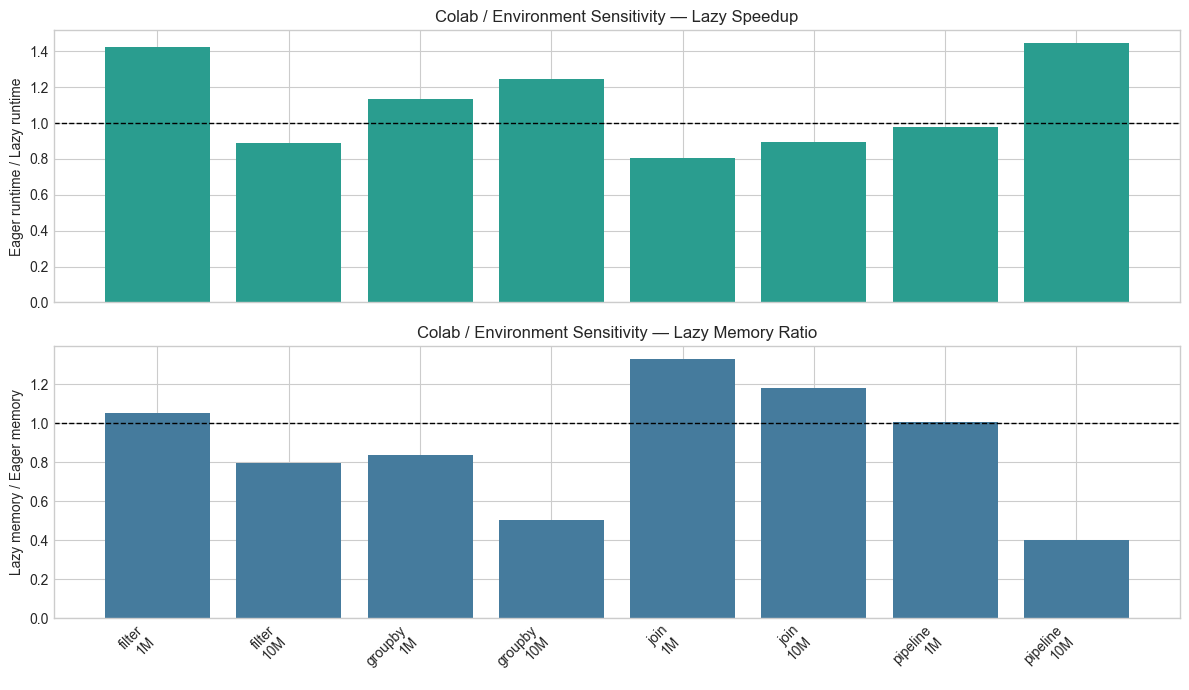

In [68]:
plot_support_ratios(
    colab_ratio,
    "Colab / Environment Sensitivity",
    SUPPORT_COLAB_ORDER,
    "support_colab_environment_ratios.png",
)


### Nhận xét

Biểu đồ Colab cho thấy kết quả Lazy-vs-Eager thay đổi đáng kể trong môi trường constrained. Đường ngang tại `1.0` là mốc so sánh: với speedup, giá trị lớn hơn `1.0` nghĩa là Lazy nhanh hơn; với memory ratio, giá trị nhỏ hơn `1.0` nghĩa là Lazy dùng ít memory hơn.

Ở biểu đồ speedup, Lazy nhanh hơn Eager ở `filter 1M`, `groupby 1M`, `groupby 10M`, và `pipeline 10M`. Trong đó, `pipeline 10M` và `filter 1M` có lợi thế Lazy rõ nhất. Tuy nhiên, Lazy vẫn chậm hơn Eager ở `filter 10M`, `join 1M`, và `join 10M`. `Pipeline 1M` gần như tương đương, vì speedup nằm rất gần mốc `1.0`.

Ở biểu đồ memory ratio, Lazy dùng ít memory hơn Eager ở nhiều trường hợp như `filter 10M`, `groupby 1M`, `groupby 10M`, và đặc biệt là `pipeline 10M`. Điều này cho thấy trong môi trường Colab, Lazy có thể giúp giảm peak memory ở một số workload, nhất là `groupby` và `pipeline`.

Ngược lại, `join` vẫn là workload bất lợi cho Lazy. Cả `join 1M` và `join 10M` đều có speedup nhỏ hơn `1.0` và memory ratio lớn hơn `1.0`, nghĩa là Eager vừa nhanh hơn vừa dùng ít memory hơn. Đây là kết quả nhất quán với main benchmark.

Tóm lại, Colab result cho thấy Lazy có thể trở nên cạnh tranh hơn trong môi trường bị giới hạn tài nguyên, đặc biệt ở `groupby` và `pipeline`. Tuy nhiên, kết quả cũng cho thấy tính nhạy cảm với môi trường chạy, nên không nên dùng Colab result để thay thế ranking chính từ main real-data benchmark.

### 12.4 Supporting Evidence Summary

Bảng dưới đây gom ba supporting groups lại ở cấp workload. Đây là summary để đọc nhanh: nhóm nào làm Lazy advantage tăng/giảm, và nhóm nào cho thấy Eager/Lazy dùng memory thấp hơn. Các dòng này vẫn chỉ là supporting evidence, không thay thế main conclusion từ Benchmark.


In [69]:
supporting_group_summary = pd.concat(
    [physical_summary, stress_summary, colab_summary],
    ignore_index=True,
)

supporting_group_summary = supporting_group_summary[[
    "support_group", "workload", "mean_lazy_speedup", "runtime_reading",
    "mean_lazy_memory_ratio", "memory_reading", "n_points",
]].sort_values(["support_group", "workload"])

save_table(supporting_group_summary, "polars_lazy_vs_eager_supporting_group_summary.csv")
supporting_group_summary


Saved results\table\polars_lazy_vs_eager_supporting_group_summary.csv


,support_group,workload,mean_lazy_speedup,runtime_reading,mean_lazy_memory_ratio,memory_reading,n_points
8,colab_environment,filter,1.155741,Lazy faster,0.922875,Lazy lower memory,2
9,colab_environment,groupby,1.189320,Lazy faster,0.671268,Lazy lower memory,2
10,colab_environment,join,0.850083,Eager faster,1.255511,Eager lower memory,2
11,colab_environment,pipeline,1.211656,Lazy faster,0.704958,Lazy lower memory,2
0,physical_scaling,filter,0.721805,Eager faster,0.816399,Lazy lower memory,3
1,physical_scaling,groupby,1.746784,Lazy faster,0.495404,Lazy lower memory,3
2,physical_scaling,join,0.342595,Eager faster,0.973384,Similar,3
3,physical_scaling,pipeline,1.312692,Lazy faster,0.610949,Lazy lower memory,3
4,synthetic_stress,filter,0.653975,Eager faster,0.822130,Lazy lower memory,2
5,synthetic_stress,groupby,2.435487,Lazy faster,0.391368,Lazy lower memory,2


### Nhận xét

Bảng supporting evidence summary cho thấy các nhóm hỗ trợ không hoàn toàn đồng nhất với main benchmark, nhưng chúng giúp làm rõ khi nào Lazy có thể có lợi hơn hoặc kém ổn định hơn Eager. Vì các nhóm này thay đổi điều kiện benchmark như physical size, synthetic stress hoặc môi trường Colab, chúng chỉ nên được dùng làm bằng chứng bổ sung, không thay thế kết luận chính từ main real-data benchmark.

Ở cả ba nhóm supporting, `groupby` là workload có xu hướng ủng hộ Lazy rõ nhất. Lazy nhanh hơn trong cả `physical_scaling`, `synthetic_stress`, và `colab_environment`, đồng thời cũng dùng ít peak memory hơn Eager ở cả ba nhóm. Điều này củng cố nhận định rằng `groupby` là workload mà Lazy có thể phát huy lợi thế tốt, đặc biệt khi dữ liệu lớn, skewed hoặc môi trường có memory pressure.

`Pipeline` cũng thường có lợi cho Lazy, nhưng kém ổn định hơn `groupby`. Lazy nhanh hơn và dùng ít memory hơn trong `physical_scaling` và `colab_environment`, nhưng trong `synthetic_stress`, Eager lại nhanh hơn dù Lazy vẫn dùng ít memory hơn. Điều này cho thấy pipeline benefit của Lazy phụ thuộc nhiều vào đặc điểm dữ liệu và môi trường chạy.

`Filter` có kết quả mixed. Trong `colab_environment`, Lazy nhanh hơn và dùng ít memory hơn, nhưng trong `physical_scaling` và `synthetic_stress`, Eager nhanh hơn về runtime trong khi Lazy vẫn dùng ít memory hơn. Vì vậy, với `filter`, Lazy có thể có lợi về memory, nhưng runtime advantage không ổn định.

`Join` là workload ổn định nhất theo hướng bất lợi cho Lazy. Trong cả ba supporting groups, Eager đều nhanh hơn Lazy. Về memory, Eager tốt hơn trong Colab, còn physical scaling và synthetic stress chỉ gần tương đương. Điều này nhất quán với main benchmark, nơi `join` cũng là workload mà Eager có lợi thế rõ nhất.

Tóm lại, supporting evidence cho thấy Lazy có lợi thế mạnh và ổn định nhất ở `groupby`, khá tốt nhưng nhạy điều kiện ở `pipeline`, mixed ở `filter`, và kém ổn định nhất ở `join`. Các kết quả này củng cố kết luận chính rằng Lazy không phải lựa chọn tốt hơn trong mọi trường hợp; hiệu quả phụ thuộc mạnh vào workload, dataset shape và môi trường chạy.

## 13. Practical Recommendation: When to Use Lazy vs Eager

Recommendation dưới đây được tính từ result thật. Rule đơn giản:

- Nếu Lazy nhanh hơn rõ ràng và không dùng memory cao hơn nhiều, recommend Lazy.
- Nếu Eager nhanh hơn rõ ràng, recommend Eager.
- Nếu runtime tương tự, ưu tiên mode có memory thấp hơn; nếu memory cũng tương tự, Eager là đủ cho workflow đơn giản.


In [70]:
def recommend_mode(row):
    speedup = row["mean_lazy_speedup"]
    memory_ratio = row["mean_lazy_memory_ratio"]
    if speedup > 1.10 and memory_ratio <= 1.10:
        return "Lazy"
    if speedup > 1.10 and memory_ratio > 1.10:
        return "Lazy if runtime matters"
    if speedup < 0.90 and memory_ratio >= 0.90:
        return "Eager"
    if speedup < 0.90 and memory_ratio < 0.90:
        return "Depends on runtime vs memory"
    if memory_ratio < 0.90:
        return "Lazy if memory matters"
    if memory_ratio > 1.10:
        return "Eager if memory matters"
    return "Eager is enough"

recommendations = workload_interpretation[[
    "workload",
    "mean_lazy_speedup",
    "overall_faster_mode",
    "mean_lazy_memory_ratio",
    "overall_lower_memory_mode",
]].copy()
recommendations["recommended_mode"] = recommendations.apply(recommend_mode, axis=1)
recommendations["reason"] = recommendations.apply(
    lambda row: f"mean speedup={row['mean_lazy_speedup']:.2f}x; memory ratio={row['mean_lazy_memory_ratio']:.2f}",
    axis=1,
)
recommendations["memory_note"] = recommendations["overall_lower_memory_mode"].map({
    "Lazy": "Lazy uses less peak memory on average.",
    "Eager": "Eager uses less peak memory on average.",
    "Similar": "Peak memory is broadly similar on average.",
})
recommendations = recommendations.sort_values("workload")

save_table(recommendations, "polars_lazy_vs_eager_recommendations.csv")
recommendations[["workload", "recommended_mode", "reason", "memory_note"]]


Saved results\table\polars_lazy_vs_eager_recommendations.csv


,workload,recommended_mode,reason,memory_note
2,filter,Eager is enough,mean speedup=1.03x; memory ratio=1.08,Eager uses less peak memory on average.
0,groupby,Lazy if runtime matters,mean speedup=1.88x; memory ratio=1.33,Eager uses less peak memory on average.
3,join,Eager,mean speedup=0.37x; memory ratio=1.24,Eager uses less peak memory on average.
1,pipeline,Lazy if runtime matters,mean speedup=1.70x; memory ratio=1.22,Eager uses less peak memory on average.


### Nhận xét

Bảng recommendation chuyển các kết quả benchmark thành gợi ý sử dụng thực tế cho từng workload. Kết luận chính là không nên mặc định chọn Lazy cho mọi trường hợp. Việc chọn Lazy hay Eager nên dựa trên trade-off giữa runtime và peak memory.

Với `filter`, recommendation là `Eager is enough`. Mean speedup của Lazy chỉ khoảng `1.03x`, gần như tương đương Eager, trong khi memory ratio khoảng `1.08`, nghĩa là Lazy dùng nhiều peak memory hơn trung bình. Vì vậy, với filter đơn giản, Eager là lựa chọn đủ tốt và dễ dùng hơn.

Với `groupby`, recommendation là `Lazy if runtime matters`. Lazy có lợi thế runtime rõ với mean speedup khoảng `1.88x`, nhưng memory ratio khoảng `1.33`, nghĩa là Lazy dùng nhiều peak memory hơn trung bình. Do đó, Lazy phù hợp khi ưu tiên tốc độ, đặc biệt với dataset lớn, nhưng cần kiểm tra memory nếu môi trường bị giới hạn RAM.

Với `join`, recommendation là `Eager`. Lazy có mean speedup chỉ khoảng `0.37x`, tức là chậm hơn Eager rõ rệt, đồng thời cũng dùng nhiều peak memory hơn trung bình. Đây là workload mà Eager là lựa chọn tốt hơn cả về runtime lẫn memory trong benchmark này.

Với `pipeline`, recommendation là `Lazy if runtime matters`. Lazy có mean speedup khoảng `1.70x`, cho thấy lợi thế runtime đáng kể, đặc biệt ở dataset lớn. Tuy nhiên, memory ratio khoảng `1.22`, nên Lazy vẫn dùng nhiều peak memory hơn trung bình. Vì vậy, Lazy phù hợp cho pipeline lớn khi runtime là ưu tiên chính, nhưng không nên xem là lựa chọn tiết kiệm memory mặc định.

Tóm lại, recommendation thực tế là: dùng Eager cho `join`, Eager là đủ cho `filter`, và dùng Lazy cho `groupby` hoặc `pipeline` khi mục tiêu chính là giảm runtime. Nếu môi trường bị giới hạn memory, cần kiểm tra peak memory riêng trước khi chọn Lazy.

## 14. Final Conclusion

Final conclusion nên trả lời lại 6 research questions dựa trên các bảng đã tính ở trên:

1. Lazy có consistently faster không?
2. Workload nào hưởng lợi nhiều nhất từ Lazy?
3. Workload nào Eager nhanh hơn hoặc memory tốt hơn?
4. Lazy có reduce memory pressure không?
5. Lazy-vs-Eager có thay đổi theo dataset size không?
6. Recommendation cuối cùng cho Polars execution mode là gì?


In [71]:
consistency = pd.DataFrame({
    "question": [
        "Is Lazy consistently faster?",
        "Workload with strongest Lazy benefit",
        "Workloads where Eager is faster or similar",
        "Does Lazy reduce memory pressure?",
        "Does behavior change with dataset size?",
        "Recommendation source",
    ],
    "answer_from_results": [
        "Yes" if (speedup_by_size["lazy_speedup"] > 1.0).all() else "No; see speedup_by_size for workload-size exceptions.",
        mean_speedup_by_workload.sort_values("mean_lazy_speedup", ascending=False).iloc[0]["workload"],
        ", ".join(mean_speedup_by_workload.loc[mean_speedup_by_workload["mean_lazy_speedup"] <= 1.05, "workload"].astype(str)) or "None by mean speedup threshold.",
        "Yes on average for all workloads" if (mean_memory_ratio_by_workload["mean_lazy_memory_ratio"] < 1.0).all() else "Mixed; see memory ratio tables.",
        "Yes" if (speedup_wide["speedup_change_50M_minus_1M"].abs() > 0.10).any() else "Only mildly in these results.",
        "Use recommendations table; it is computed from mean speedup and memory ratio.",
    ],
})

save_table(consistency, "polars_lazy_vs_eager_final_answers.csv")
consistency


Saved results\table\polars_lazy_vs_eager_final_answers.csv


,question,answer_from_results
0,Is Lazy consistently faster?,No; see speedup_by_size for workload-size exce...
1,Workload with strongest Lazy benefit,groupby
2,Workloads where Eager is faster or similar,"filter, join"
3,Does Lazy reduce memory pressure?,Mixed; see memory ratio tables.
4,Does behavior change with dataset size?,Yes
5,Recommendation source,Use recommendations table; it is computed from...
